# AutoML percentile correction on Favorita Grocery Sales (XGBoost)

This version selects percentiles by overall **MSE** (metric mode).


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from mlforecast.auto import xgboost_space
import optuna

from utilsforecast.losses import rmse, mse, bias, mae

def eval_metrics(valid_df, preds_df, model_col: str):
    df = valid_df.merge(preds_df, on=["unique_id", "ds"], how="inner")
    return {
        "rows": len(df),
        "rmse": float(rmse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mse": float(mse(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "bias": float(bias(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
        "mae": float(mae(df, models=[model_col], id_col="unique_id", target_col="y")[model_col].mean()),
    }

def rmse_loss(df, train_df):  # train_df is unused here
    # df has columns: ['unique_id', 'ds', 'cutoff', 'y', 'model']
    return rmse(df, models=['model'], id_col='unique_id', target_col='y')['model'].mean()


/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_dir = 'data'
favorita_group = 'FavoritaComplete'  # 'Favorita200' or 'FavoritaComplete'
favorita_dir = f'{data_dir}/favorita'
favorita_start_date = '2017-01-01'

def coerce_favorita_ds(ds):
    ds = pd.Series(ds)
    if pd.api.types.is_datetime64_any_dtype(ds):
        return pd.to_datetime(ds)

    numeric = pd.to_numeric(ds, errors='coerce')
    if numeric.notna().all():
        values = numeric.astype('int64')
        if values.abs().max() > 10**14:
            return pd.to_datetime(values, unit='ns')
        if values.abs().max() > 10**11:
            return pd.to_datetime(values, unit='ms')
        return pd.to_datetime(values, unit='s')

    return pd.to_datetime(ds)


def read_favorita_table(directory, name, usecols=None, dtype=None):
    feather_path = f'{directory}/{name}.feather'
    csv_path = f'{directory}/{name}.csv'
    if pd.io.common.file_exists(feather_path):
        df = pd.read_feather(feather_path)
        if usecols is not None:
            existing = [c for c in usecols if c in df.columns]
            df = df[existing].copy()
        return df
    if pd.io.common.file_exists(csv_path):
        kwargs = {}
        if usecols is not None:
            kwargs['usecols'] = lambda c: c in set(usecols)
        if dtype is not None:
            kwargs['dtype'] = dtype
        return pd.read_csv(csv_path, **kwargs)
    raise FileNotFoundError(f'Favorita file {name} not found in {directory} as feather or csv.')


def load_favorita_bottom(directory, group='Favorita200', start_date='2017-01-01'):
    temporal = read_favorita_table(
        directory,
        'train',
        usecols=['date', 'item_nbr', 'store_nbr', 'unit_sales', 'onpromotion'],
    )

    temporal = temporal.rename(columns={'date': 'ds', 'unit_sales': 'y'})
    temporal['ds'] = coerce_favorita_ds(temporal['ds'])
    temporal['y'] = pd.to_numeric(temporal['y'], errors='coerce').fillna(0.0).astype('float32')
    temporal['onpromotion'] = pd.to_numeric(temporal.get('onpromotion', 0), errors='coerce').fillna(0).astype('int8')
    temporal['item_nbr'] = pd.to_numeric(temporal['item_nbr'], errors='coerce').astype('int32')
    temporal['store_nbr'] = pd.to_numeric(temporal['store_nbr'], errors='coerce').astype('int16')

    temporal = temporal[temporal['ds'] >= pd.Timestamp(start_date)].copy()

    all_items = np.sort(temporal['item_nbr'].unique())
    if group == 'Favorita200':
        rng = np.random.default_rng(1)
        items = np.sort(rng.choice(all_items, size=200, replace=False))
    elif group == 'Favorita500':
        rng = np.random.default_rng(1)
        items = np.sort(rng.choice(all_items, size=500, replace=False))
    elif group == 'FavoritaComplete':
        items = all_items
    else:
        raise ValueError('group must be one of Favorita200, Favorita500, FavoritaComplete')

    temporal = temporal[temporal['item_nbr'].isin(items)].copy()
    stores = np.sort(temporal['store_nbr'].unique())

    temporal = (
        temporal.groupby(['item_nbr', 'store_nbr', 'ds'], as_index=False)
        .agg(y=('y', 'sum'), onpromotion=('onpromotion', 'max'))
    )

    items_meta = read_favorita_table(directory, 'items', usecols=['item_nbr', 'family', 'perishable'])
    items_meta['item_nbr'] = pd.to_numeric(items_meta['item_nbr'], errors='coerce').astype('int32')
    items_meta = items_meta[items_meta['item_nbr'].isin(items)].copy()
    items_meta['family'] = items_meta['family'].fillna('unknown').astype('string')
    items_meta['perishable'] = pd.to_numeric(items_meta.get('perishable', 0), errors='coerce').fillna(0).astype('int8')

    stores_meta = read_favorita_table(directory, 'stores', usecols=['store_nbr', 'city', 'type'])
    stores_meta['store_nbr'] = pd.to_numeric(stores_meta['store_nbr'], errors='coerce').astype('int16')
    stores_meta = stores_meta[stores_meta['store_nbr'].isin(stores)].copy()
    stores_meta['city'] = stores_meta['city'].fillna('unknown').astype('string')
    stores_meta['type'] = stores_meta['type'].fillna('unknown').astype('string')

    transactions = read_favorita_table(directory, 'transactions', usecols=['date', 'store_nbr', 'transactions'])
    transactions = transactions.rename(columns={'date': 'ds'})
    transactions['ds'] = coerce_favorita_ds(transactions['ds'])
    transactions['store_nbr'] = pd.to_numeric(transactions['store_nbr'], errors='coerce').astype('int16')
    transactions['transactions'] = pd.to_numeric(transactions['transactions'], errors='coerce').fillna(0).astype('float32')
    transactions = transactions[transactions['store_nbr'].isin(stores)].copy()

    oil = read_favorita_table(directory, 'oil', usecols=['date', 'dcoilwtico'])
    oil = oil.rename(columns={'date': 'ds', 'dcoilwtico': 'oil_price'})
    oil['ds'] = coerce_favorita_ds(oil['ds'])
    oil['oil_price'] = pd.to_numeric(oil['oil_price'], errors='coerce')

    holidays = read_favorita_table(directory, 'holidays_events', usecols=['date', 'transferred'])
    holidays = holidays.rename(columns={'date': 'ds'})
    holidays['ds'] = coerce_favorita_ds(holidays['ds'])
    holidays['transferred'] = holidays['transferred'].astype(str).str.lower().isin(['true', '1', 'yes']).astype('int8')
    holidays = holidays.groupby('ds', as_index=False).agg(transferred=('transferred', 'max'))

    date_min = temporal['ds'].min()
    date_max = temporal['ds'].max()
    dates = pd.date_range(date_min, date_max, freq='D')

    grid = pd.MultiIndex.from_product(
        [items, stores, dates],
        names=['item_nbr', 'store_nbr', 'ds'],
    ).to_frame(index=False)

    oil_full = pd.DataFrame({'ds': dates}).merge(oil, on='ds', how='left')
    oil_full['oil_price'] = oil_full['oil_price'].interpolate(limit_direction='both').ffill().bfill().astype('float32')

    full = (
        grid
        .merge(temporal, on=['item_nbr', 'store_nbr', 'ds'], how='left')
        .merge(items_meta, on='item_nbr', how='left')
        .merge(stores_meta, on='store_nbr', how='left')
        .merge(transactions, on=['store_nbr', 'ds'], how='left')
        .merge(oil_full, on='ds', how='left')
        .merge(holidays, on='ds', how='left')
    )

    full['y'] = full['y'].fillna(0.0).astype('float32')
    full['onpromotion'] = full['onpromotion'].fillna(0).astype('int8')
    full['transactions'] = full['transactions'].fillna(0.0).astype('float32')
    full['oil_price'] = full['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
    full['transferred'] = full['transferred'].fillna(0).astype('int8')
    full['family'] = full['family'].fillna('unknown').astype('category')
    full['city'] = full['city'].fillna('unknown').astype('category')
    full['type'] = full['type'].fillna('unknown').astype('category')
    full['item_nbr'] = full['item_nbr'].astype('Int32').astype('category')
    full['store_nbr'] = full['store_nbr'].astype('Int16').astype('category')
    full['perishable'] = full['perishable'].fillna(0).astype('int8')

    full['unique_id'] = (
        full['item_nbr'].astype(str) + '__store_' + full['store_nbr'].astype(str)
    )

    cols = [
        'unique_id', 'ds', 'y',
        'item_nbr', 'store_nbr', 'family', 'city', 'type',
        'onpromotion', 'perishable', 'transferred',
        'transactions', 'oil_price',
    ]
    return full[cols].sort_values(['unique_id', 'ds']).reset_index(drop=True)

df = load_favorita_bottom(
    directory=favorita_dir,
    group=favorita_group,
    start_date=favorita_start_date,
)

# Optional: subsample ids for faster experiments
MAX_IDS = 50000
all_ids = df['unique_id'].unique()
if MAX_IDS is not None and len(all_ids) > MAX_IDS:
    rng = np.random.default_rng(0)
    keep_ids = rng.choice(all_ids, size=MAX_IDS, replace=False)
    df = df[df['unique_id'].isin(keep_ids)].copy()

h = 7
season_length = 7

# Percentile levels used for correction (customizable)


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_97674/3017048032.py:133: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full['oil_price'] = full['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')


In [5]:
df.shape

(11350000, 13)

In [6]:
df.unique_id.nunique()

50000

In [7]:
def rolling_holdout_splits(df, h, n_test_sets, time_col='ds'):
    # assume all ids share same ds grid
    all_ds = pd.to_datetime(sorted(df[time_col].unique()))
    max_ds = all_ds[-1]
    step = pd.Timedelta(days=h)

    for k in range(n_test_sets):
        test_end = max_ds - k * step
        test_start = test_end - pd.Timedelta(days=h - 1)

        train = df[df[time_col] < test_start]
        test = df[(df[time_col] >= test_start) & (df[time_col] <= test_end)]

        yield k, train.reset_index(drop=True), test.reset_index(drop=True)


In [8]:
def tweedie_space(trial):
    params = xgboost_space(trial)
    params["objective"] = "reg:tweedie"
    params["tweedie_variance_power"] = 1.3
    params["eval_metric"] = "tweedie-nloglik@1.5"
    return params


In [9]:
from sklearn.preprocessing import FunctionTransformer
from mlforecast.target_transforms import LocalStandardScaler, GlobalSklearnTransformer

from mlforecast.lag_transforms import (RollingMean, ExponentiallyWeightedMean, ExpandingMax, ExpandingMin,
                                       RollingStd)

LAGS = [
    [1],
    [1, 2, 3],
    [1, 2, 3, 7],
    [1, 7, 14],
    [1, 7, 14, 28],
]

LAG_TRANSFORMS = [
    {1: [ExponentiallyWeightedMean(0.9),
         ExpandingMax(),
         ExpandingMin(),
         RollingStd(window_size=7, min_samples=1),
         RollingStd(window_size=14, min_samples=3),
         RollingMean(window_size=7, min_samples=1),
         RollingMean(window_size=14, min_samples=3),
         RollingMean(window_size=60, min_samples=1),
         ]
     },
   # {
   #     1: [ExponentiallyWeightedMean(0.9)],
   #     7: [RollingMean(window_size=3, min_samples=1)],
   # },
]

DATE_FEATURES = ["year", "month", "week", "weekday"]  # standard calendar features

def my_init_config(trial):
    lags_idx = trial.suggest_int("lags_idx", 0, len(LAGS) - 1)
    ltfm_idx = trial.suggest_int("lag_tfms_idx", 0, len(LAG_TRANSFORMS) - 1)
    return {
        "target_transforms": None,   # no differencing
        "lags": LAGS[lags_idx],
        "lag_transforms": LAG_TRANSFORMS[ltfm_idx],
        "date_features": DATE_FEATURES,
    }


In [7]:
df.shape

(49252644, 13)

In [ ]:
STATIC_FEATURES = ['item_nbr', 'store_nbr', 'family', 'city', 'type', 'perishable']
DYNAMIC_FEATURES = ['onpromotion', 'transactions', 'oil_price', 'transferred']
FUTURE_EXOG_COLS = ['unique_id', 'ds'] + DYNAMIC_FEATURES

def my_fit_config(trial):
    return {
        "dropna": False,
        "static_features": STATIC_FEATURES,
    }
    
# Percentile levels used for correction (customizable)
CORRECTION_LEVELS = list(range(1, 50, 1))

season_length = 7
h = 7
n_windows = 5
step_size = 7
num_samples = 10
    
n_test_sets = 10

rmse_base_test = []
mse_base_test = []
mae_base_test = []
bias_base_test = []

rmse_corr_test = []
mse_corr_test = []
mae_corr_test = []
bias_corr_test = []

cv_rmse_normal_cv = []
cv_bias_normal_cv = []

cv_rmse_corr_cv = []
cv_bias_corr_cv = []

rmse_base_only_corrected_test = []
mse_base_only_corrected_test = []
mae_base_only_corrected_test = []
bias_base_only_corrected_test = []

rmse_corr_only_corrected_test = []
mse_corr_only_corrected_test = []
mae_corr_only_corrected_test = []
bias_corr_only_corrected_test = []

delta_corr = []
delta_raw = []

share_correction = []
p_val_cv = []

group_sum_records = []
group_correction_records = []
forecast_records = []
selected_percentile_records = []
fold_metric_records = []
train_history_records = []
forecast_records = []
selected_percentile_records = []
fold_metric_records = []

def xgb_space_with_native_cats(trial):
    params = xgboost_space(trial)
    params.update({
        'enable_categorical': True,
        'tree_method': 'hist',
    })
    return params

for i, train_i, test_i in rolling_holdout_splits(df, h, n_test_sets):
    from mlforecast.auto import AutoMLForecast, AutoXGBoost, PredictionIntervals, xgboost_space
    
    #auto_base = AutoMLForecast(
    #models={"xgb": AutoXGBoost(config=tweedie_space)},
    #freq="D",
    #init_config=my_init_config,
    #fit_config=my_fit_config,
    # reuse_cv_splits=True
    #)

    auto_corr = AutoMLForecast(
        #models={"xgb": AutoXGBoost(config=tweedie_space)},
        models={"xgb": AutoXGBoost(config=xgb_space_with_native_cats)},
        freq="D",
        init_config=my_init_config,
        fit_config=my_fit_config,
        reuse_cv_splits=True
    )
    
    print(i, train_i.ds.min(), train_i.ds.max(), " | ", 
          test_i.ds.min(), test_i.ds.max())

    length_ids = train_i.groupby('unique_id').ds.nunique().reset_index()

    good_ids = length_ids[length_ids.ds > 55].unique_id.unique()

    train_i = train_i[train_i.unique_id.isin(good_ids)].copy()
    test_i = test_i[test_i.unique_id.isin(good_ids)].copy()

    future_exog = test_i[FUTURE_EXOG_COLS].copy()
    future_exog['onpromotion'] = future_exog['onpromotion'].fillna(0).astype('int8')
    future_exog['transactions'] = future_exog['transactions'].fillna(0.0).astype('float32')
    future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
    future_exog['transferred'] = future_exog['transferred'].fillna(0).astype('int8')
    
    #study_kwargs = {"sampler": optuna.samplers.TPESampler()} 
    # Train base model:
    #auto_base.fit(
    #df=train_i,
    #n_windows=n_windows,
    #h=h,
    #num_samples=num_samples,
    #optimize_kwargs=optimize_kwargs,
    #step_size=5,
    #loss=mse_loss,
    #study_kwargs={"sampler": optuna.samplers.TPESampler()}
    # prediction_intervals=PredictionIntervals(n_windows=n_windows, h=h),
    #)

    # preds_base = auto_base.predict(h=test_i.ds.nunique())
    # metrics_base = eval_metrics(test_i, preds_base, "xgb")
    
    # Train corrected model:
    auto_corr.fit(
    df=train_i,
    n_windows=n_windows,
    h=h,
    num_samples=num_samples,
    step_size=step_size,
    prediction_intervals=PredictionIntervals(n_windows=3, h=h),
    percentile_correction=True,
    # percentile_correction_mode="metric",
    percentile_correction_metric="rmse", 
    percentile_correction_mode="bias",
    percentile_correction_strict_bias=True,
    percentile_correction_metric_kwargs=None,
    percentile_correction_levels=CORRECTION_LEVELS,
    compute_corrected_cv_metrics=True,
    loss=rmse_loss,
    study_kwargs={"sampler": optuna.samplers.TPESampler()}
    )
    
    preds_corr = auto_corr.predict(h=test_i.ds.nunique(), X_df=future_exog)
    
    name = "xgb"
    corr = auto_corr.percentile_correction_[name]
    corr_ids = list(corr["id_to_col"].keys())
    raw_preds = auto_corr.models_[name].predict(
        h=test_i.ds.nunique(),
        X_df=future_exog,
        level=corr["levels"],  # make sure percentile cols exist
    )
    
    metrics_corr = eval_metrics(test_i, preds_corr, "xgb")
    metrics_base = eval_metrics(test_i, raw_preds, "xgb")

    # Split series into 5 groups based on training mean sales per day,
    # isolating the top 5% as its own segment.
    series_groups = train_i.groupby('unique_id', as_index=False).agg(
        mean_sales_per_day=('y', 'mean')
    )
    series_groups['sales_rank_pct'] = series_groups['mean_sales_per_day'].rank(method='first', pct=True)
    non_top_mask = series_groups['sales_rank_pct'] <= 0.95
    series_groups['sales_group'] = 'G5_top_5pct'
    series_groups.loc[non_top_mask, 'sales_group'] = pd.qcut(
        series_groups.loc[non_top_mask, 'sales_rank_pct'],
        q=4,
        labels=['G1_lowest', 'G2_low', 'G3_mid', 'G4_high'],
    ).astype(str)

    train_history_fold = train_i.merge(series_groups, on='unique_id', how='left').copy()
    train_history_fold['fold'] = i
    train_history_records.append(
        train_history_fold[['fold', 'unique_id', 'ds', 'y', 'mean_sales_per_day', 'sales_group']].copy()
    )

    preds_compare = (
        test_i.merge(
            raw_preds[['unique_id', 'ds', 'xgb']].rename(columns={'xgb': 'raw_pred'}),
            on=['unique_id', 'ds'],
            how='left',
        )
        .merge(
            preds_corr[['unique_id', 'ds', 'xgb']].rename(columns={'xgb': 'corr_pred'}),
            on=['unique_id', 'ds'],
            how='left',
        )
        .merge(series_groups, on='unique_id', how='left')
    )

    selected_map_df = pd.DataFrame(
        {
            'unique_id': list(corr['id_to_col'].keys()),
            'selected_col': list(corr['id_to_col'].values()),
        }
    )
    if not selected_map_df.empty:
        selected_parts = selected_map_df['selected_col'].str.extract(
            r'^(?P<model>.+)-(?P<selected_side>lo|hi)-(?P<selected_percentile>\d+(?:\.\d+)?)$'
        )
        selected_map_df = pd.concat([selected_map_df, selected_parts], axis=1)
        selected_map_df['selected_percentile'] = pd.to_numeric(
            selected_map_df['selected_percentile'], errors='coerce'
        )

    preds_compare = preds_compare.merge(selected_map_df, on='unique_id', how='left')
    preds_compare['was_corrected'] = preds_compare['selected_col'].notna()
    preds_compare['fold'] = i
    preds_compare['horizon'] = preds_compare.groupby('unique_id', observed=True).cumcount() + 1
    preds_compare['abs_adjustment'] = np.abs(preds_compare['corr_pred'] - preds_compare['raw_pred'])
    preds_compare['raw_error'] = preds_compare['raw_pred'] - preds_compare['y']
    preds_compare['corr_error'] = preds_compare['corr_pred'] - preds_compare['y']
    preds_compare['raw_abs_error'] = np.abs(preds_compare['raw_error'])
    preds_compare['corr_abs_error'] = np.abs(preds_compare['corr_error'])
    preds_compare['improved'] = preds_compare['corr_abs_error'] < preds_compare['raw_abs_error']

    forecast_records.append(
        preds_compare[[
            'fold', 'unique_id', 'ds', 'horizon', 'y', 'raw_pred', 'corr_pred',
            'raw_error', 'corr_error', 'raw_abs_error', 'corr_abs_error',
            'abs_adjustment', 'improved', 'mean_sales_per_day', 'sales_group',
            'was_corrected', 'selected_col', 'selected_side', 'selected_percentile'
        ]].copy()
    )
    if not selected_map_df.empty:
        selected_percentile_records.append(
            series_groups.merge(selected_map_df, on='unique_id', how='inner').assign(fold=i)
        )
    fold_metric_records.append(
        pd.DataFrame({
            'fold': [i],
            'rmse_base': [metrics_base['rmse']],
            'rmse_corr': [metrics_corr['rmse']],
            'mse_base': [metrics_base['mse']],
            'mse_corr': [metrics_corr['mse']],
            'bias_base': [metrics_base['bias']],
            'bias_corr': [metrics_corr['bias']],
            'n_ids': [train_i['unique_id'].nunique()],
            'n_corrected_ids': [len(corr_ids)],
        })
    )

    per_id_horizon = (
        preds_compare.groupby(['sales_group', 'unique_id'], as_index=False)
        .agg(
            true_sum=('y', 'sum'),
            raw_sum=('raw_pred', 'sum'),
            corrected_sum=('corr_pred', 'sum'),
        )
    )

    grouped_sums = (
        per_id_horizon.groupby('sales_group', as_index=False)
        .agg(
            true_sum=('true_sum', 'mean'),
            raw_sum=('raw_sum', 'mean'),
            corrected_sum=('corrected_sum', 'mean'),
        )
    )
    grouped_sums['fold'] = i
    group_sum_records.append(grouped_sums)

    all_per_id = (
        preds_compare.groupby('unique_id', as_index=False)
        .agg(
            true_sum=('y', 'sum'),
            raw_sum=('raw_pred', 'sum'),
            corrected_sum=('corr_pred', 'sum'),
        )
    )
    group_sum_records.append(pd.DataFrame({
        'sales_group': ['ALL'],
        'true_sum': [all_per_id['true_sum'].mean()],
        'raw_sum': [all_per_id['raw_sum'].mean()],
        'corrected_sum': [all_per_id['corrected_sum'].mean()],
        'fold': [i],
    }))

    corr_ids_set = set(map(str, corr_ids))
    series_groups['is_corrected'] = series_groups['unique_id'].astype(str).isin(corr_ids_set)

    group_correction = series_groups.groupby('sales_group', as_index=False).agg(
        n_ids=('unique_id', 'nunique'),
        n_corrected_ids=('is_corrected', 'sum'),
        mean_sales_min=('mean_sales_per_day', 'min'),
        mean_sales_max=('mean_sales_per_day', 'max'),
    )
    group_correction['correction_coverage'] = (
        group_correction['n_corrected_ids'] / group_correction['n_ids']
    )

    adjustment_stats = preds_compare.groupby('sales_group').apply(
        lambda g: pd.Series({
            'adjustment_share': np.abs(g['corr_pred'] - g['raw_pred']).sum() / (np.abs(g['raw_pred']).sum() + 1e-12),
            'improved_share': (np.abs(g['corr_pred'] - g['y']) < np.abs(g['raw_pred'] - g['y'])).mean(),
        }),
    ).reset_index()
    group_correction = group_correction.merge(adjustment_stats, on='sales_group', how='left')
    group_correction['fold'] = i
    group_correction_records.append(group_correction)
    group_correction_records.append(pd.DataFrame({
        'sales_group': ['ALL'],
        'n_ids': [series_groups['unique_id'].nunique()],
        'n_corrected_ids': [series_groups['is_corrected'].sum()],
        'mean_sales_min': [series_groups['mean_sales_per_day'].min()],
        'mean_sales_max': [series_groups['mean_sales_per_day'].max()],
        'correction_coverage': [series_groups['is_corrected'].mean()],
        'adjustment_share': [np.abs(preds_compare['corr_pred'] - preds_compare['raw_pred']).sum() / (np.abs(preds_compare['raw_pred']).sum() + 1e-12)],
        'improved_share': [(np.abs(preds_compare['corr_pred'] - preds_compare['y']) < np.abs(preds_compare['raw_pred'] - preds_compare['y'])).mean()],
        'fold': [i],
    }))
    
    metrics_corr_only_corrected = eval_metrics(test_i[test_i.unique_id.isin(corr_ids)], 
                                                 preds_corr[preds_corr.unique_id.isin(corr_ids)], "xgb")
    metrics_base_only_corrected = eval_metrics(test_i[test_i.unique_id.isin(corr_ids)], 
                                                 raw_preds[raw_preds.unique_id.isin(corr_ids)], "xgb")
    
    rmse_base = metrics_base['rmse']
    mse_base = metrics_base['mse']
    mae_base = metrics_base['mae']
    bias_base = metrics_base['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_base_only_corrected = metrics_base_only_corrected['rmse']
    mse_base_only_corrected = metrics_base_only_corrected['mse']
    mae_base_only_corrected = metrics_base_only_corrected['mae']
    bias_base_only_corrected = metrics_base_only_corrected['bias']
    
    rmse_corr = metrics_corr['rmse']
    mse_corr = metrics_corr['mse']
    mae_corr = metrics_corr['mae']
    bias_corr = metrics_corr['bias']
    
    rmse_corr_only_corrected = metrics_corr_only_corrected ['rmse']
    mse_corr_only_corrected = metrics_corr_only_corrected ['mse']
    mae_corr_only_corrected = metrics_corr_only_corrected ['mae']
    bias_corr_only_corrected = metrics_corr_only_corrected ['bias']
    
    cv_rmse_normal = auto_corr.cv_metrics_["xgb"]['rmse']
    cv_bias_normal = auto_corr.cv_metrics_["xgb"]['bias']
    
    cv_rmse_corr = auto_corr.cv_metrics_corrected_["xgb"]['rmse']
    cv_bias_corr = auto_corr.cv_metrics_corrected_["xgb"]['bias']
    
    delta_corr_temp = (preds_corr[preds_corr.unique_id.isin(corr_ids)].xgb.sum() / 
                  test_i[test_i.unique_id.isin(corr_ids)].y.sum() - 1)
    delta_raw_temp = (raw_preds[raw_preds.unique_id.isin(corr_ids)].xgb.sum() / 
                 test_i[test_i.unique_id.isin(corr_ids)].y.sum() - 1 )
    
    #############
    # save outputs
    rmse_base_test.append(rmse_base)
    mse_base_test.append(mse_base)
    mae_base_test.append(mae_base)
    bias_base_test.append(bias_base)
    
    rmse_corr_test.append(rmse_corr)
    mse_corr_test.append(mse_corr)
    mae_corr_test.append(mae_corr)
    bias_corr_test.append(bias_corr)
    
    rmse_base_only_corrected_test.append(rmse_base_only_corrected)
    mse_base_only_corrected_test.append(mse_base_only_corrected)
    mae_base_only_corrected_test.append(mae_base_only_corrected)
    bias_base_only_corrected_test.append(bias_base_only_corrected)
    
    rmse_corr_only_corrected_test.append(rmse_corr_only_corrected)
    mse_corr_only_corrected_test.append(mse_corr_only_corrected)
    mae_corr_only_corrected_test.append(mae_corr_only_corrected)
    bias_corr_only_corrected_test.append(bias_corr_only_corrected)
    
    cv_rmse_normal_cv.append(cv_rmse_normal)
    cv_bias_normal_cv.append(cv_bias_normal)
    
    cv_rmse_corr_cv.append(cv_rmse_corr)
    cv_bias_corr_cv.append(cv_bias_corr)
    
    delta_corr.append(delta_corr_temp)
    delta_raw.append(delta_raw_temp)
    ###############
    # Get base and corrected forecast from correction model:
    

    # raw predictions WITH the needed percentile columns
    #raw_preds = auto_corr.models_[name].predict(
    #    h=test_i.ds.nunique(),
    #    level=corr["levels"],  # make sure percentile cols exist
    #)

    # corrected predictions (auto_corr.predict applies correction)
    preds_optimal = auto_corr.predict(h=test_i.ds.nunique(), X_df=future_exog)
    ###############
    preds_all = raw_preds.merge(preds_optimal, on=['ds', 'unique_id'])
    
    corr_ids_str = set(map(str, corr_ids))
    preds_all = preds_all[preds_all.unique_id.astype(str).isin(corr_ids_str)]
    
    preds_all = preds_all.merge(test_i, on=['ds', 'unique_id'])

    preds_all['res_base'] = abs(preds_all.xgb_x - preds_all.y)
    preds_all['res_best'] = abs(preds_all.xgb_y - preds_all.y)

    preds_all['flag'] = np.where(preds_all.res_best < preds_all.res_base, 1, 0)
    share_correction.append(preds_all['flag'].mean())
    #############
    # Run t-test:
    t_stat, p_val = stats.ttest_ind(preds_all.xgb_x, 
                                preds_all.xgb_y, 
                                equal_var=True)  
    p_val_cv.append(p_val)

0 2017-01-01 00:00:00 2017-08-08 00:00:00  |  2017-08-09 00:00:00 2017-08-15 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_97674/2126620373.py:105: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
[I 2026-05-04 22:21:05,480] A new study created in memory with name: no-name-5b8d9c18-43fc-451b-9716-193013b2193f
[I 2026-05-04 22:30:01,577] Trial 0 finished with value: 3.6188933849334717 and parameters: {'n_estimators': 967, 'max_depth': 10, 'learning_rate': 0.0011863778461481149, 'subsample': 0.4594411918594441, 'colsample_bytree': 0.9102366082512262, 'reg_lambda': 0.015728906520990703, 'reg_alpha': 1.2132691211710063e-05, 'min_child_weight': 5, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 3.6188933849334717.
[I 2026-05-04 22:34:02,709] Trial 1 finished with value: 3.024562358856201 and parameters: {'n_estimators': 866, 'ma

1 2017-01-01 00:00:00 2017-08-01 00:00:00  |  2017-08-02 00:00:00 2017-08-08 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_97674/2126620373.py:105: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
[I 2026-05-04 23:27:02,023] A new study created in memory with name: no-name-bfe3fbb2-1a02-410c-8514-e23f731f824f
[I 2026-05-04 23:27:37,326] Trial 0 finished with value: 5.097293853759766 and parameters: {'n_estimators': 277, 'max_depth': 2, 'learning_rate': 0.0013510146474384913, 'subsample': 0.3535007248846975, 'colsample_bytree': 0.9110480476802375, 'reg_lambda': 7.432577672121299e-08, 'reg_alpha': 2.7212662913997245e-06, 'min_child_weight': 5, 'lags_idx': 4, 'lag_tfms_idx': 0}. Best is trial 0 with value: 5.097293853759766.
[I 2026-05-04 23:28:03,795] Trial 1 finished with value: 3.043844699859619 and parameters: {'n_estimators': 156, 'max_

2 2017-01-01 00:00:00 2017-07-25 00:00:00  |  2017-07-26 00:00:00 2017-08-01 00:00:00


...

/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_97674/2126620373.py:105: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
[I 2026-05-05 02:57:09,551] A new study created in memory with name: no-name-6e1b20fb-4654-4f88-ab3e-233df7a51bc2
[I 2026-05-05 02:58:59,182] Trial 0 finished with value: 3.613185167312622 and parameters: {'n_estimators': 336, 'max_depth': 9, 'learning_rate': 0.0036840374615002107, 'subsample': 0.18889873629156767, 'colsample_bytree': 0.27324598721310484, 'reg_lambda': 0.07534784503016281, 'reg_alpha': 0.09010818788190283, 'min_child_weight': 5, 'lags_idx': 4, 'lag_tfms_idx': 0}. Best is trial 0 with value: 3.613185167312622.
[I 2026-05-05 03:01:09,340] Trial 1 finished with value: 2.918632745742798 and parameters: {'n_estimators': 347, 'max_dep

8 2017-01-01 00:00:00 2017-06-13 00:00:00  |  2017-06-14 00:00:00 2017-06-20 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_97674/2126620373.py:105: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
[I 2026-05-05 03:53:07,177] A new study created in memory with name: no-name-85f1ead7-874e-45ef-92d8-0898df30ad34
[I 2026-05-05 03:53:51,554] Trial 0 finished with value: 3.410421848297119 and parameters: {'n_estimators': 234, 'max_depth': 6, 'learning_rate': 0.007199776053048874, 'subsample': 0.13721258269368708, 'colsample_bytree': 0.17122873830625204, 'reg_lambda': 0.011822664748320394, 'reg_alpha': 0.0010434610461036603, 'min_child_weight': 4, 'lags_idx': 3, 'lag_tfms_idx': 0}. Best is trial 0 with value: 3.410421848297119.
[I 2026-05-05 03:54:42,719] Trial 1 finished with value: 3.7255923748016357 and parameters: {'n_estimators': 360, 'max_

9 2017-01-01 00:00:00 2017-06-06 00:00:00  |  2017-06-07 00:00:00 2017-06-13 00:00:00


/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_97674/2126620373.py:105: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_exog['oil_price'] = future_exog['oil_price'].fillna(method='ffill').fillna(method='bfill').fillna(0.0).astype('float32')
[I 2026-05-05 04:48:57,492] A new study created in memory with name: no-name-ebd0a2f3-363f-43b6-a734-d356b6c84b56
[I 2026-05-05 04:51:11,046] Trial 0 finished with value: 3.1539478302001953 and parameters: {'n_estimators': 457, 'max_depth': 10, 'learning_rate': 0.011662804885260215, 'subsample': 0.4854303537421708, 'colsample_bytree': 0.32095164303959806, 'reg_lambda': 0.5429662221025876, 'reg_alpha': 1.2527498060662415e-06, 'min_child_weight': 8, 'lags_idx': 0, 'lag_tfms_idx': 0}. Best is trial 0 with value: 3.1539478302001953.
[I 2026-05-05 04:53:15,471] Trial 1 finished with value: 10.911576271057129 and parameters: {'n_estimators': 579, 'max

In [ ]:
group_order = ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct', 'ALL']

group_sum_df = pd.concat(group_sum_records, ignore_index=True)
group_correction_df = pd.concat(group_correction_records, ignore_index=True)

group_sum_df['sales_group'] = pd.Categorical(
    group_sum_df['sales_group'], categories=group_order, ordered=True
)
group_correction_df['sales_group'] = pd.Categorical(
    group_correction_df['sales_group'], categories=group_order, ordered=True
)

group_sum_df = group_sum_df.sort_values(['fold', 'sales_group']).reset_index(drop=True)
group_correction_df = group_correction_df.sort_values(['fold', 'sales_group']).reset_index(drop=True)

# fold-by-fold view
fold_view = (
    group_sum_df
    .merge(
        group_correction_df[
            ['fold', 'sales_group', 'correction_coverage', 'adjustment_share', 'improved_share']
        ],
        on=['fold', 'sales_group'],
        how='left'
    )
)

fold_view['raw_to_true_ratio'] = fold_view['raw_sum'] / fold_view['true_sum']
fold_view['corrected_to_true_ratio'] = fold_view['corrected_sum'] / fold_view['true_sum']
fold_view['raw_pct_error'] = fold_view['raw_to_true_ratio'] - 1
fold_view['corrected_pct_error'] = fold_view['corrected_to_true_ratio'] - 1
fold_view['raw_gap'] = fold_view['raw_sum'] - fold_view['true_sum']
fold_view['corrected_gap'] = fold_view['corrected_sum'] - fold_view['true_sum']
fold_view['gap_reduction'] = fold_view['corrected_gap'].abs() - fold_view['raw_gap'].abs()


In [ ]:
# aggregated summary across all folds
group_summary = (
    fold_view
    .groupby('sales_group', as_index=False)
    .agg(
        true_sum=('true_sum', 'sum'),
        raw_sum=('raw_sum', 'sum'),
        corrected_sum=('corrected_sum', 'sum'),
        raw_gap=('raw_gap', 'sum'),
        corrected_gap=('corrected_gap', 'sum'),
        correction_coverage=('correction_coverage', 'mean'),
        adjustment_share=('adjustment_share', 'mean'),
        improved_share=('improved_share', 'mean'),
    )
)

group_summary['raw_to_true_ratio'] = group_summary['raw_sum'] / group_summary['true_sum']
group_summary['corrected_to_true_ratio'] = group_summary['corrected_sum'] / group_summary['true_sum']
group_summary['raw_pct_error'] = group_summary['raw_to_true_ratio'] - 1
group_summary['corrected_pct_error'] = group_summary['corrected_to_true_ratio'] - 1
group_summary['abs_gap_improvement'] = group_summary['raw_gap'].abs() - group_summary['corrected_gap'].abs()

group_summary

/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_82888/1263074093.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fold_view


,sales_group,true_sum,raw_sum,corrected_sum,raw_gap,corrected_gap,correction_coverage,adjustment_share,improved_share,raw_to_true_ratio,corrected_to_true_ratio,raw_pct_error,corrected_pct_error,abs_gap_improvement
0,G1_lowest,0.000,318.145874,101.474365,318.145860,101.474367,1.000000,0.655474,0.876190,inf,inf,inf,inf,216.671492
1,G2_low,329.628,499.932312,376.489044,170.304302,46.861043,0.627778,0.328646,0.544444,1.516656,1.142163,0.516656,0.142163,123.443259
2,G3_mid,1648.119,1647.045654,1645.778809,-1.073353,-2.340130,0.018182,0.002292,0.006926,0.999349,0.998580,-0.000651,-0.001420,-1.266777
3,G4_high,5798.007,5551.629883,5557.383301,-246.377361,-240.623577,0.066667,0.013041,0.041270,0.957507,0.958499,-0.042493,-0.041501,5.753784
4,G5_top_5pct,6188.707,5835.498047,6490.544434,-353.208953,301.837281,0.133333,0.078781,0.041270,0.942927,1.048772,-0.057073,0.048772,51.371672
5,ALL,13964.461,13852.251953,14171.669922,-112.209474,207.209044,0.418667,0.073361,0.354857,0.991965,1.014838,-0.008035,0.014838,-94.999570


In [ ]:
np.mean(delta_corr)

/Users/janrathfelder/miniconda3/envs/mlforecast-dev/lib/python3.10/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


np.float64(nan)

In [ ]:
np.mean(delta_raw)

np.float64(inf)

In [ ]:
len(mae_corr_only_corrected_test)

15

In [ ]:
# mae improvement

np.mean(mae_corr_only_corrected_test[4:]) / np.mean(mae_base_only_corrected_test[4:]) - 1

np.float64(-0.2539953556905128)

In [ ]:
# rmse improvement

np.mean(rmse_corr_only_corrected_test[4:]) / np.mean(rmse_base_only_corrected_test[4:]) - 1

np.float64(-0.19648427608553076)

In [ ]:
# share of rmse for corr better than for base

a = np.array(rmse_corr_only_corrected_test)
b = np.array(rmse_base_only_corrected_test)

mask = a < b
count = mask.sum()
idxs = np.where(mask)[0]
len(idxs) / len(a)

0.8666666666666667

In [ ]:
# share of bias for corr better than for base

a = np.array(np.abs(bias_corr_only_corrected_test))
b = np.array(np.abs(bias_base_only_corrected_test))

mask = a < b
count = mask.sum()
idxs = np.where(mask)[0]
len(idxs) / len(a)

0.6

In [ ]:
share_correction

[np.float64(0.9659863945578231),
 np.float64(0.9006211180124224),
 np.float64(0.21428571428571427),
 np.float64(0.9642857142857143),
 np.float64(0.9795918367346939),
 np.float64(0.1),
 np.float64(0.948051948051948),
 np.float64(1.0),
 np.float64(0.8961038961038961),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9428571428571428),
 np.float64(0.8819875776397516),
 np.float64(0.8819875776397516)]

In [ ]:
np.mean(share_correction)

np.float64(0.8450505946779239)

In [ ]:
forecast_df = pd.concat(forecast_records, ignore_index=True)
selected_percentiles_df = pd.concat(selected_percentile_records, ignore_index=True)
fold_metrics_df = pd.concat(fold_metric_records, ignore_index=True)
train_history_df = pd.concat(train_history_records, ignore_index=True)

forecast_df = forecast_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)
selected_percentiles_df = selected_percentiles_df.sort_values(['fold', 'sales_group', 'unique_id']).reset_index(drop=True)
fold_metrics_df = fold_metrics_df.sort_values('fold').reset_index(drop=True)
train_history_df = train_history_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)


## Corrected-items-only diagnostics

Zoom in on the series that were actually corrected under strict bias selection. These tables exclude all uncorrected items before computing bias and RMSE.


In [ ]:
import numpy as np
import pandas as pd

required = ['forecast_df']
missing = [name for name in required if name not in globals()]
if missing:
    print(f'Missing {missing}. Run the loop and forecast_df assembly cells first.')
elif forecast_df.empty:
    print('forecast_df is empty. Run the loop cell first.')
else:
    corrected_forecast_df = forecast_df[forecast_df['was_corrected']].copy()

    if corrected_forecast_df.empty:
        print('No corrected items found. With strict bias selection this can happen if no series passes the correction rule.')
    else:
        def corrected_metric_summary(frame):
            raw_rmse = np.sqrt(np.mean(np.square(frame['raw_error'])))
            corrected_rmse = np.sqrt(np.mean(np.square(frame['corr_error'])))
            raw_bias = frame['raw_error'].mean()
            corrected_bias = frame['corr_error'].mean()
            return pd.Series({
                'n_rows': len(frame),
                'n_ids': frame['unique_id'].nunique(),
                'raw_rmse': raw_rmse,
                'corrected_rmse': corrected_rmse,
                'rmse_delta': corrected_rmse - raw_rmse,
                'rmse_ratio': corrected_rmse / (raw_rmse + 1e-12),
                'raw_bias': raw_bias,
                'corrected_bias': corrected_bias,
                'abs_bias_delta': abs(corrected_bias) - abs(raw_bias),
                'abs_bias_ratio': abs(corrected_bias) / (abs(raw_bias) + 1e-12),
                'improved_share': frame['improved'].mean(),
                'mean_abs_adjustment': frame['abs_adjustment'].mean(),
            })

        def summarize_by(frame, by, sort=True, **groupby_kwargs):
            rows = []
            for key, group in frame.groupby(by, **groupby_kwargs):
                summary = corrected_metric_summary(group).to_dict()
                if isinstance(by, str):
                    summary[by] = key
                else:
                    for col, value in zip(by, key):
                        summary[col] = value
                rows.append(summary)
            out = pd.DataFrame(rows)
            if sort and not out.empty:
                out = out.sort_values(by).reset_index(drop=True)
            return out

        corrected_items_summary = corrected_metric_summary(corrected_forecast_df).to_frame().T
        corrected_items_by_fold = summarize_by(corrected_forecast_df, 'fold')
        corrected_items_by_group = summarize_by(
            corrected_forecast_df, 'sales_group', observed=True
        )
        corrected_items_by_side = summarize_by(
            corrected_forecast_df, 'selected_side', dropna=False
        )

        display(corrected_items_summary.round(4))
        display(corrected_items_by_fold.round(4))
        display(corrected_items_by_group.round(4))
        display(corrected_items_by_side.round(4))


In [ ]:
def plot_uid_fold(uid, fold, history_points=None):
    hist = train_history_df[
        (train_history_df['fold'] == fold) &
        (train_history_df['unique_id'] == uid)
    ].copy().sort_values('ds')

    fut = forecast_df[
        (forecast_df['fold'] == fold) &
        (forecast_df['unique_id'] == uid)
    ].copy().sort_values('ds')

    if hist.empty or fut.empty:
        print('No data for this uid/fold')
        return

    if history_points is not None:
        hist = hist.tail(history_points)

    meta = fut[['sales_group', 'mean_sales_per_day', 'was_corrected', 'selected_col']].iloc[0]

    plt.figure(figsize=(12, 5))
    plt.plot(hist['ds'], hist['y'], label='Train history', color='black', alpha=0.8)
    plt.plot(fut['ds'], fut['raw_pred'], label='Raw forecast', alpha=0.8)
    plt.plot(fut['ds'], fut['corr_pred'], label='Corrected forecast', alpha=0.8)
    plt.plot(fut['ds'], fut['y'], label='True', alpha=0.8)
    plt.title(
        f"fold={fold} | uid={uid} | group={meta['sales_group']} | "
        f"mean_sales={meta['mean_sales_per_day']:.3f} | "
        f"corrected={meta['was_corrected']} | "
        f"choice={meta['selected_col']}"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(
        fut[[
            'ds', 'y', 'raw_pred', 'corr_pred',
            'raw_error', 'corr_error',
            'raw_abs_error', 'corr_abs_error',
            'abs_adjustment', 'improved',
            'selected_side', 'selected_percentile'
        ]]
    )


def plot_random_from_each_group(fold=0, n_per_group=2, corrected_only=False, history_points=60, seed=42):
    rng = np.random.default_rng(seed)
    groups = ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct']

    base = (
        forecast_df[forecast_df['fold'] == fold][
            ['unique_id', 'sales_group', 'was_corrected', 'mean_sales_per_day']
        ]
        .drop_duplicates()
    )

    for group in groups:
        cand = base[base['sales_group'] == group].copy()
        if corrected_only:
            cand = cand[cand['was_corrected']]

        if cand.empty:
            print(f'{group}: no ids available')
            continue

        sampled = rng.choice(cand['unique_id'].to_numpy(), size=min(n_per_group, len(cand)), replace=False)
        print(f'\n=== {group} ===')
        for uid in sampled:
            plot_uid_fold(uid, fold=fold, history_points=history_points)



=== G1_lowest ===


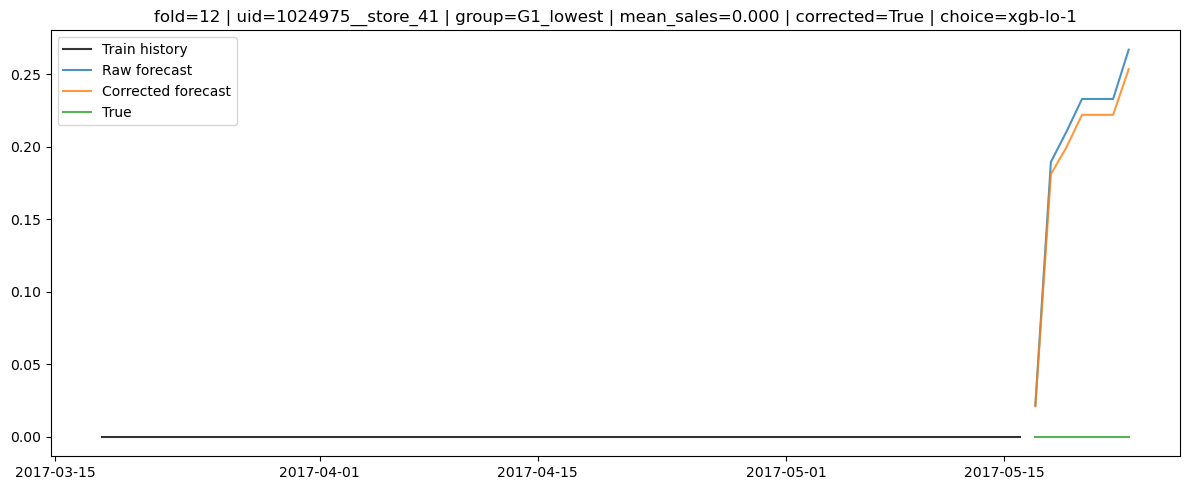

,ds,y,raw_pred,corr_pred,raw_error,corr_error,raw_abs_error,corr_abs_error,abs_adjustment,improved,selected_side,selected_percentile
4214,2017-05-17,0.0,0.021756,0.021090,0.021756,0.021090,0.021756,0.021090,0.000666,True,lo,1.0
4215,2017-05-18,0.0,0.189638,0.181221,0.189638,0.181221,0.189638,0.181221,0.008416,True,lo,1.0
4216,2017-05-19,0.0,0.210529,0.199797,0.210529,0.199797,0.210529,0.199797,0.010732,True,lo,1.0
4217,2017-05-20,0.0,0.233103,0.222156,0.233103,0.222156,0.233103,0.222156,0.010947,True,lo,1.0
4218,2017-05-21,0.0,0.233103,0.222156,0.233103,0.222156,0.233103,0.222156,0.010947,True,lo,1.0
4219,2017-05-22,0.0,0.233103,0.222156,0.233103,0.222156,0.233103,0.222156,0.010947,True,lo,1.0
4220,2017-05-23,0.0,0.267094,0.253659,0.267094,0.253659,0.267094,0.253659,0.013435,True,lo,1.0



=== G2_low ===


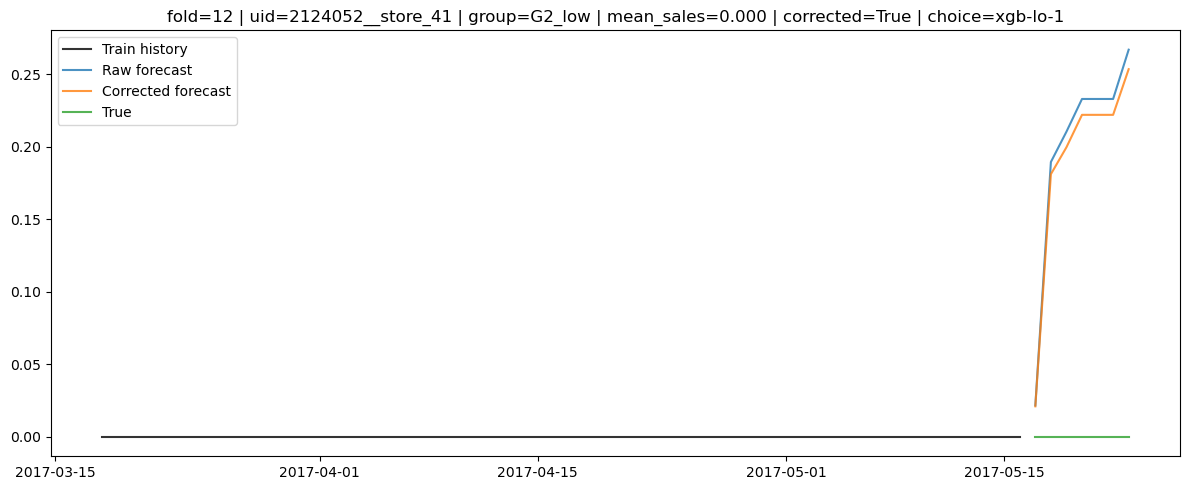

,ds,y,raw_pred,corr_pred,raw_error,corr_error,raw_abs_error,corr_abs_error,abs_adjustment,improved,selected_side,selected_percentile
4466,2017-05-17,0.0,0.021756,0.021090,0.021756,0.021090,0.021756,0.021090,0.000666,True,lo,1.0
4467,2017-05-18,0.0,0.189638,0.181221,0.189638,0.181221,0.189638,0.181221,0.008416,True,lo,1.0
4468,2017-05-19,0.0,0.210529,0.199797,0.210529,0.199797,0.210529,0.199797,0.010732,True,lo,1.0
4469,2017-05-20,0.0,0.233103,0.222156,0.233103,0.222156,0.233103,0.222156,0.010947,True,lo,1.0
4470,2017-05-21,0.0,0.233103,0.222156,0.233103,0.222156,0.233103,0.222156,0.010947,True,lo,1.0
4471,2017-05-22,0.0,0.233103,0.222156,0.233103,0.222156,0.233103,0.222156,0.010947,True,lo,1.0
4472,2017-05-23,0.0,0.267094,0.253659,0.267094,0.253659,0.267094,0.253659,0.013435,True,lo,1.0



=== G3_mid ===


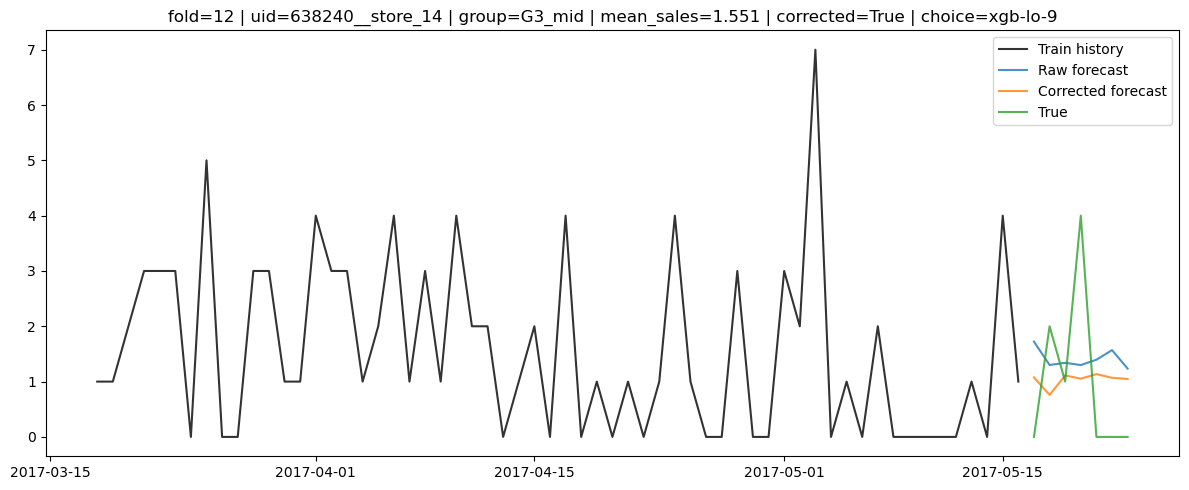

,ds,y,raw_pred,corr_pred,raw_error,corr_error,raw_abs_error,corr_abs_error,abs_adjustment,improved,selected_side,selected_percentile
4508,2017-05-17,0.0,1.722491,1.076129,1.722491,1.076129,1.722491,1.076129,0.646363,True,lo,9.0
4509,2017-05-18,2.0,1.300378,0.759561,-0.699622,-1.240439,0.699622,1.240439,0.540817,False,lo,9.0
4510,2017-05-19,1.0,1.339078,1.111480,0.339078,0.111480,0.339078,0.111480,0.227598,True,lo,9.0
4511,2017-05-20,4.0,1.299032,1.052891,-2.700968,-2.947109,2.700968,2.947109,0.246142,False,lo,9.0
4512,2017-05-21,0.0,1.395470,1.135620,1.395470,1.135620,1.395470,1.135620,0.259850,True,lo,9.0
4513,2017-05-22,0.0,1.568831,1.068675,1.568831,1.068675,1.568831,1.068675,0.500157,True,lo,9.0
4514,2017-05-23,0.0,1.234856,1.048011,1.234856,1.048011,1.234856,1.048011,0.186845,True,lo,9.0


G4_high: no ids available

=== G5_top_5pct ===


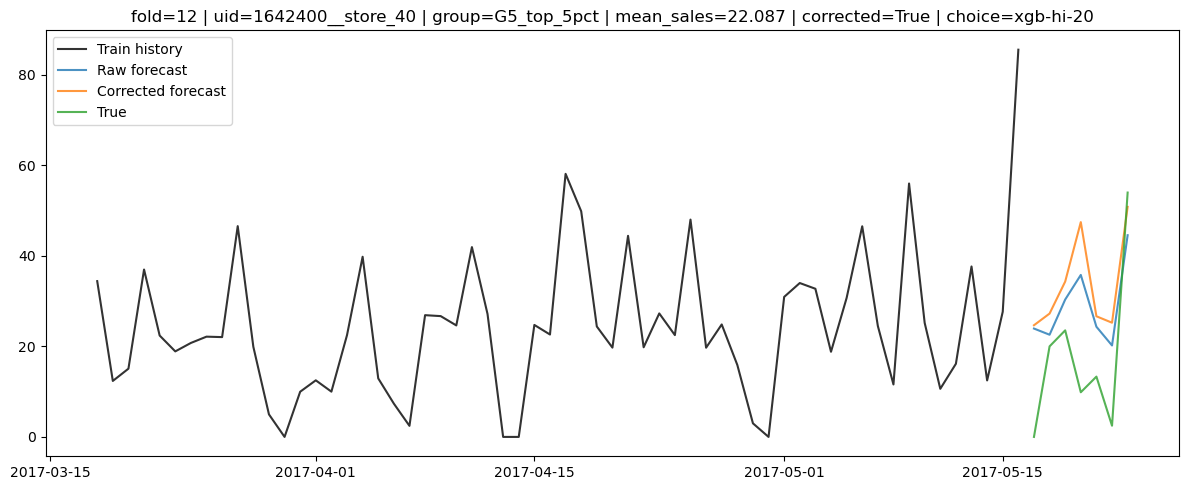

,ds,y,raw_pred,corr_pred,raw_error,corr_error,raw_abs_error,corr_abs_error,abs_adjustment,improved,selected_side,selected_percentile
4333,2017-05-17,0.000,23.936453,24.665192,23.936453,24.665192,23.936453,24.665192,0.728739,False,hi,20.0
4334,2017-05-18,20.000,22.569588,27.244848,2.569588,7.244848,2.569588,7.244848,4.675261,False,hi,20.0
4335,2017-05-19,23.536,30.340141,34.311253,6.804141,10.775253,6.804141,10.775253,3.971111,False,hi,20.0
4336,2017-05-20,9.864,35.779518,47.444206,25.915518,37.580206,25.915518,37.580206,11.664688,False,hi,20.0
4337,2017-05-21,13.318,24.336737,26.645342,11.018737,13.327342,11.018737,13.327342,2.308605,False,hi,20.0
4338,2017-05-22,2.473,20.199322,25.224316,17.726322,22.751316,17.726322,22.751316,5.024994,False,hi,20.0
4339,2017-05-23,53.973,44.552807,50.819889,-9.420193,-3.153111,9.420193,3.153111,6.267082,True,hi,20.0


In [ ]:
plot_random_from_each_group(fold=12, n_per_group=1, corrected_only=True, history_points=60, seed=42)

In [ ]:
group_order = ['G1_lowest', 'G2_low', 'G3_mid', 'G4_high', 'G5_top_5pct', 'ALL']

group_sum_df = pd.concat(group_sum_records, ignore_index=True)
group_correction_df = pd.concat(group_correction_records, ignore_index=True)
forecast_df = pd.concat(forecast_records, ignore_index=True)
selected_percentiles_df = pd.concat(selected_percentile_records, ignore_index=True)
fold_metrics_df = pd.concat(fold_metric_records, ignore_index=True)
train_history_df = pd.concat(train_history_records, ignore_index=True)

forecast_df = forecast_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)
selected_percentiles_df = selected_percentiles_df.sort_values(['fold', 'sales_group', 'unique_id']).reset_index(drop=True)
fold_metrics_df = fold_metrics_df.sort_values('fold').reset_index(drop=True)
train_history_df = train_history_df.sort_values(['fold', 'unique_id', 'ds']).reset_index(drop=True)

group_sum_summary = group_sum_df.groupby('sales_group', as_index=False).agg(
    true_sum=('true_sum', 'sum'),
    raw_sum=('raw_sum', 'sum'),
    corrected_sum=('corrected_sum', 'sum'),
)
group_sum_summary['raw_to_true_ratio'] = group_sum_summary['raw_sum'] / group_sum_summary['true_sum']
group_sum_summary['corrected_to_true_ratio'] = group_sum_summary['corrected_sum'] / group_sum_summary['true_sum']
group_sum_summary['raw_pct_error'] = group_sum_summary['raw_to_true_ratio'] - 1
group_sum_summary['corrected_pct_error'] = group_sum_summary['corrected_to_true_ratio'] - 1

group_correction_summary = group_correction_df.groupby('sales_group', as_index=False).agg(
    avg_n_ids=('n_ids', 'mean'),
    avg_corrected_ids=('n_corrected_ids', 'mean'),
    correction_coverage=('correction_coverage', 'mean'),
    adjustment_share=('adjustment_share', 'mean'),
    improved_share=('improved_share', 'mean'),
    mean_sales_min=('mean_sales_min', 'mean'),
    mean_sales_max=('mean_sales_max', 'mean'),
)

group_error_summary = forecast_df.groupby('sales_group', as_index=False).agg(
    raw_rmse=('raw_error', lambda s: np.sqrt(np.mean(np.square(s)))),
    corrected_rmse=('corr_error', lambda s: np.sqrt(np.mean(np.square(s)))),
    raw_bias=('raw_error', 'mean'),
    corrected_bias=('corr_error', 'mean'),
)
group_error_summary = pd.concat([
    group_error_summary,
    pd.DataFrame({
        'sales_group': ['ALL'],
        'raw_rmse': [np.sqrt(np.mean(np.square(forecast_df['raw_error'])))],
        'corrected_rmse': [np.sqrt(np.mean(np.square(forecast_df['corr_error'])))],
        'raw_bias': [forecast_df['raw_error'].mean()],
        'corrected_bias': [forecast_df['corr_error'].mean()],
    })
], ignore_index=True)

group_summary = group_sum_summary.merge(group_correction_summary, on='sales_group', how='left')
group_summary = group_summary.merge(group_error_summary, on='sales_group', how='left')
group_summary['sales_group'] = pd.Categorical(group_summary['sales_group'], categories=group_order, ordered=True)
group_summary = group_summary.sort_values('sales_group').reset_index(drop=True)
group_summary


,sales_group,true_sum,raw_sum,corrected_sum,raw_to_true_ratio,corrected_to_true_ratio,raw_pct_error,corrected_pct_error,avg_n_ids,avg_corrected_ids,correction_coverage,adjustment_share,improved_share,mean_sales_min,mean_sales_max,raw_rmse,corrected_rmse,raw_bias,corrected_bias
0,G1_lowest,0.000,318.145874,101.474365,inf,inf,inf,inf,12.0,12.000000,1.000000,0.655474,0.876190,0.000000,0.000000,0.287470,0.128309,0.252497,0.080535
1,G2_low,329.628,499.932312,376.489044,1.516656,1.142163,0.516656,0.142163,12.0,7.533333,0.627778,0.328646,0.544444,0.000000,0.400011,1.014203,0.979738,0.135162,0.037191
2,G3_mid,1648.119,1647.045654,1645.778809,0.999349,0.998580,-0.000651,-0.001420,11.0,0.200000,0.018182,0.002292,0.006926,0.515912,1.907854,1.900176,1.900277,-0.000929,-0.002026
3,G4_high,5798.007,5551.629883,5557.383301,0.957507,0.958499,-0.042493,-0.041501,12.0,0.800000,0.066667,0.013041,0.041270,2.280944,8.198114,4.082810,4.093218,-0.195538,-0.190971
4,G5_top_5pct,6188.707,5835.498047,6490.544434,0.942927,1.048772,-0.057073,0.048772,3.0,0.400000,0.133333,0.078781,0.041270,12.556868,21.923006,49.413011,54.322646,-1.121298,0.958213
5,ALL,13964.461,13852.251953,14171.669922,0.991965,1.014838,-0.008035,0.014838,50.0,20.933333,0.418667,0.073361,0.354857,0.000000,21.923006,12.310988,13.494696,-0.021373,0.039468


In [ ]:
group_summary[['sales_group', 'true_sum', 'raw_sum', 'corrected_sum', 'raw_to_true_ratio', 'corrected_to_true_ratio', 'raw_rmse', 'corrected_rmse', 'raw_bias', 'corrected_bias', 'correction_coverage', 'adjustment_share', 'improved_share', 'mean_sales_min', 'mean_sales_max']]


,sales_group,true_sum,raw_sum,corrected_sum,raw_to_true_ratio,corrected_to_true_ratio,raw_rmse,corrected_rmse,raw_bias,corrected_bias,correction_coverage,adjustment_share,improved_share,mean_sales_min,mean_sales_max
0,G1_lowest,0.000,318.145874,101.474365,inf,inf,0.287470,0.128309,0.252497,0.080535,1.000000,0.655474,0.876190,0.000000,0.000000
1,G2_low,329.628,499.932312,376.489044,1.516656,1.142163,1.014203,0.979738,0.135162,0.037191,0.627778,0.328646,0.544444,0.000000,0.400011
2,G3_mid,1648.119,1647.045654,1645.778809,0.999349,0.998580,1.900176,1.900277,-0.000929,-0.002026,0.018182,0.002292,0.006926,0.515912,1.907854
3,G4_high,5798.007,5551.629883,5557.383301,0.957507,0.958499,4.082810,4.093218,-0.195538,-0.190971,0.066667,0.013041,0.041270,2.280944,8.198114
4,G5_top_5pct,6188.707,5835.498047,6490.544434,0.942927,1.048772,49.413011,54.322646,-1.121298,0.958213,0.133333,0.078781,0.041270,12.556868,21.923006
5,ALL,13964.461,13852.251953,14171.669922,0.991965,1.014838,12.310988,13.494696,-0.021373,0.039468,0.418667,0.073361,0.354857,0.000000,21.923006


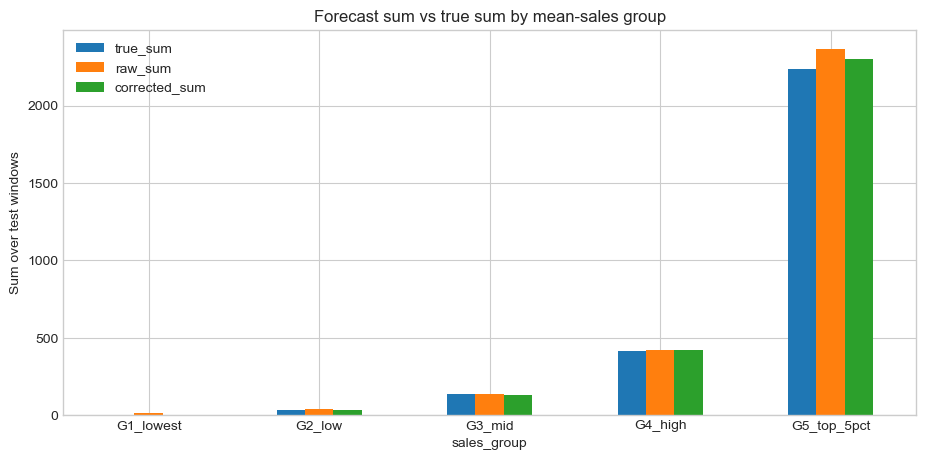

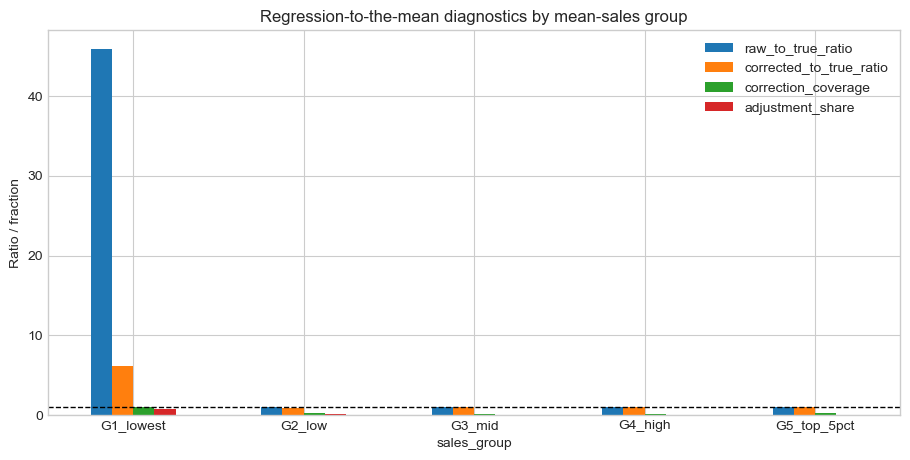

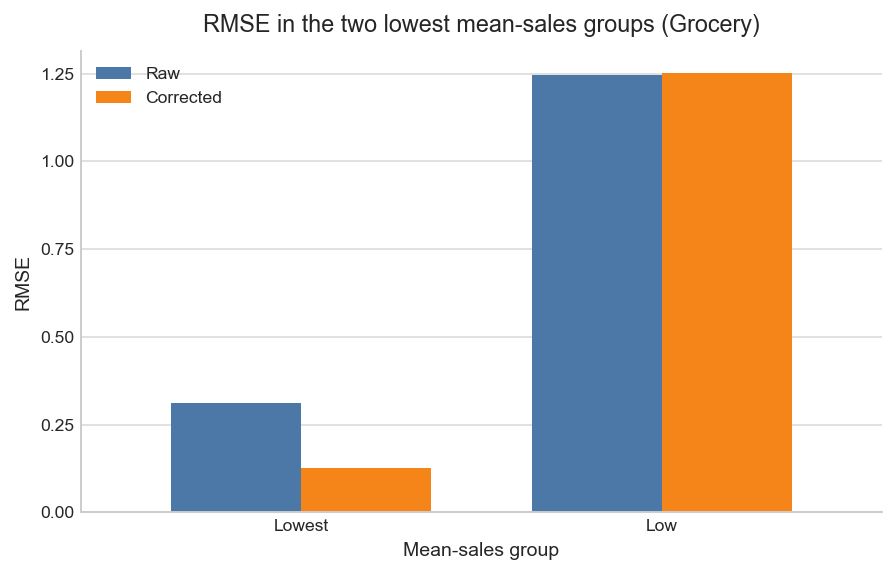

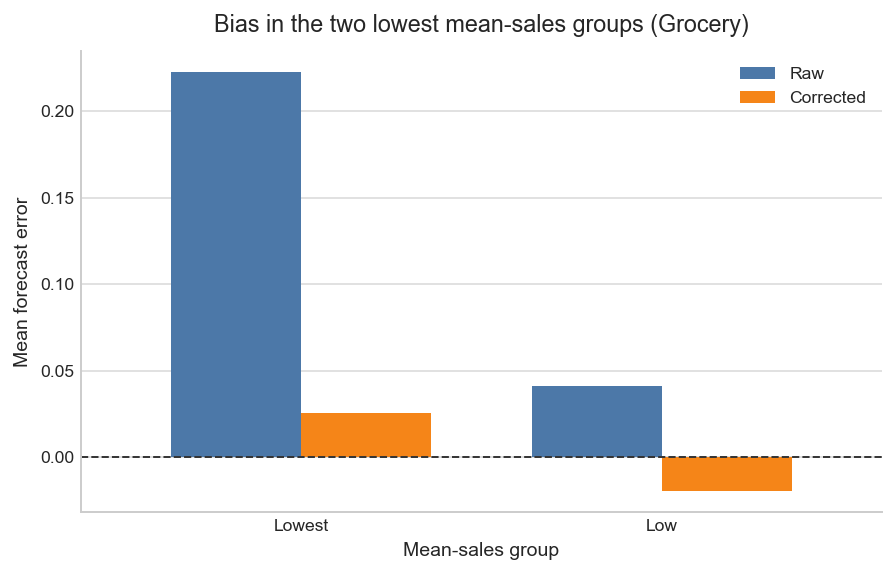

/var/folders/nk/kvcs64mn4nbfqfw1ff_czjn80000gn/T/ipykernel_48752/236471286.py:107: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,sales_group,raw_wrmse,corrected_wrmse
sales_group_label,,,
Lowest,G1_lowest,0.423357,0.405869
Low,G2_low,1.478538,1.490815


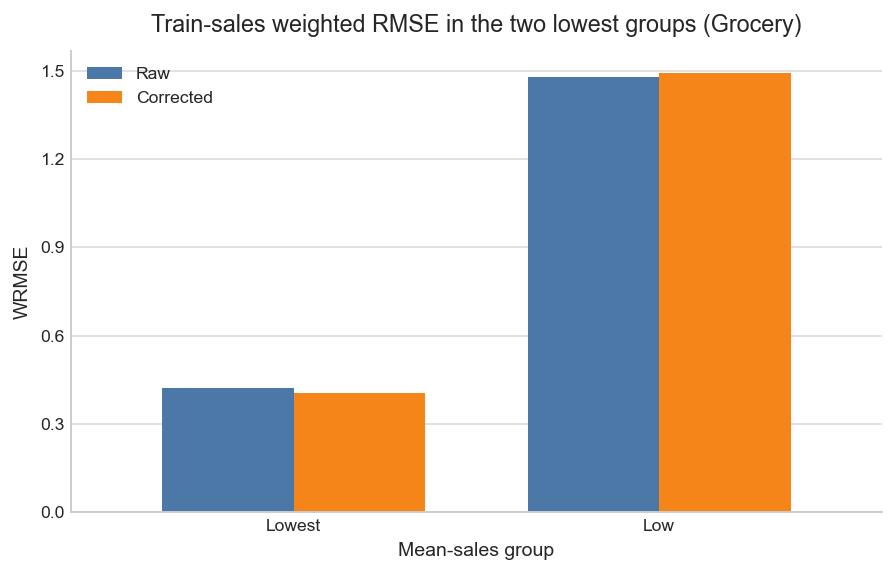

In [68]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')

plot_groups = group_summary[group_summary['sales_group'] != 'ALL'].copy()
bottom_groups = [g for g in group_order[:2] if g in set(plot_groups['sales_group'].astype(str))]
bottom_group_labels = {
    'G1_lowest': 'Lowest',
    'G2_low': 'Low',
    'G0_bottom5': 'Bottom 5%',
    'G1_low_5_to_20': '5-20%',
}

raw_color = '#4C78A8'
corrected_color = '#F58518'
grid_color = '#D9D9D9'


def scientific_barplot(ax, data, title, ylabel, hline=None):
    data.plot(kind='bar', ax=ax, color=[raw_color, corrected_color], width=0.72)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Mean-sales group', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(axis='y', color=grid_color, linewidth=0.8)
    ax.grid(axis='x', visible=False)
    if hline is not None:
        ax.axhline(hline, color='#333333', linestyle='--', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9)


# Keep the broader context plots across all groups.
ax = plot_groups.set_index('sales_group')[['true_sum', 'raw_sum', 'corrected_sum']].plot(kind='bar', figsize=(11, 5))
ax.set_title('Forecast sum vs true sum by mean-sales group')
ax.set_ylabel('Sum over test windows')
plt.xticks(rotation=0)
plt.show()

ax = plot_groups.set_index('sales_group')[['raw_to_true_ratio', 'corrected_to_true_ratio', 'correction_coverage', 'adjustment_share']].plot(kind='bar', figsize=(11, 5))
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Regression-to-the-mean diagnostics by mean-sales group')
ax.set_ylabel('Ratio / fraction')
plt.xticks(rotation=0)
plt.show()

# Focus the error plots on the two lowest mean-sales groups.
if not bottom_groups:
    print('No bottom sales groups found. Run the loop and aggregation cells first.')
else:
    bottom_summary = plot_groups[plot_groups['sales_group'].astype(str).isin(bottom_groups)].copy()
    bottom_summary['sales_group_label'] = bottom_summary['sales_group'].astype(str).map(bottom_group_labels).fillna(bottom_summary['sales_group'].astype(str))
    bottom_summary = bottom_summary.set_index('sales_group_label')

    fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
    scientific_barplot(
        ax,
        bottom_summary[['raw_rmse', 'corrected_rmse']].rename(columns={'raw_rmse': 'Raw', 'corrected_rmse': 'Corrected'}),
        'RMSE in the two lowest mean-sales groups (Grocery)',
        'RMSE',
    )
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
    scientific_barplot(
        ax,
        bottom_summary[['raw_bias', 'corrected_bias']].rename(columns={'raw_bias': 'Raw', 'corrected_bias': 'Corrected'}),
        'Bias in the two lowest mean-sales groups (Grocery)',
        'Mean forecast error',
        hline=0.0,
    )
    fig.tight_layout()
    plt.show()

    forecast_for_wrmse = None
    if 'forecast_eval_df' in globals() and forecast_eval_df is not None and not forecast_eval_df.empty:
        forecast_for_wrmse = forecast_eval_df.copy()
    elif 'forecast_df' in globals() and forecast_df is not None and not forecast_df.empty:
        forecast_for_wrmse = forecast_df.copy()

    if forecast_for_wrmse is not None and 'train_history_df' in globals() and not train_history_df.empty:
        corrected_col = 'corrected_pred' if 'corrected_pred' in forecast_for_wrmse.columns else 'corr_pred'
        if {'fold', 'unique_id', 'raw_pred', corrected_col, 'y', 'sales_group'}.issubset(forecast_for_wrmse.columns):
            train_weight_col = 'train_mean_sales' if 'train_mean_sales' in train_history_df.columns else 'mean_sales_per_day'
            weight_df = (
                train_history_df.assign(unique_id=lambda d: d['unique_id'].astype(str))
                .groupby(['fold', 'unique_id'], as_index=False)
                .agg(train_weight=(train_weight_col, 'mean'))
            )
            wrmse_df = forecast_for_wrmse.assign(unique_id=lambda d: d['unique_id'].astype(str)).merge(
                weight_df, on=['fold', 'unique_id'], how='left'
            )
            wrmse_df = wrmse_df[wrmse_df['sales_group'].astype(str).isin(bottom_groups)].copy()
            wrmse_df['weight'] = wrmse_df['train_weight'].clip(lower=0).fillna(0)
            if wrmse_df['weight'].sum() == 0:
                wrmse_df['weight'] = 1.0
            wrmse_df['raw_sq_err'] = (wrmse_df['raw_pred'] - wrmse_df['y']) ** 2
            wrmse_df['corrected_sq_err'] = (wrmse_df[corrected_col] - wrmse_df['y']) ** 2

            bottom_wrmse = (
                wrmse_df.groupby('sales_group', observed=True)
                .apply(lambda g: pd.Series({
                    'raw_wrmse': np.sqrt(np.average(g['raw_sq_err'], weights=g['weight'])),
                    'corrected_wrmse': np.sqrt(np.average(g['corrected_sq_err'], weights=g['weight'])),
                }))
                .reset_index()
            )
            bottom_wrmse['sales_group_label'] = bottom_wrmse['sales_group'].astype(str).map(bottom_group_labels).fillna(bottom_wrmse['sales_group'].astype(str))
            bottom_wrmse = bottom_wrmse.set_index('sales_group_label')
            display(bottom_wrmse)

            fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=140)
            scientific_barplot(
                ax,
                bottom_wrmse[['raw_wrmse', 'corrected_wrmse']].rename(columns={'raw_wrmse': 'Raw', 'corrected_wrmse': 'Corrected'}),
                'Train-sales weighted RMSE in the two lowest groups (Grocery)',
                'WRMSE',
            )
            fig.tight_layout()
            plt.show()
        else:
            print('Forecast diagnostics do not have the required columns for WRMSE.')
    else:
        print('Forecast diagnostics or train_history_df is empty; cannot compute WRMSE.')


## Top-item diagnostics (Grocery)
Inspect top 1% and top 25 items by mean training sales/day, and whether percentile correction is applied/improves horizon sums.


In [69]:
import numpy as np
import pandas as pd

required = ['train_history_df', 'group_correction_df']
missing = [x for x in required if x not in globals()]
if missing:
    print(f'Missing {missing}. Run loop + group diagnostics cells first.')
else:
    if 'forecast_eval_df' not in globals() or forecast_eval_df is None or (hasattr(forecast_eval_df, 'empty') and forecast_eval_df.empty):
        if 'forecast_records' in globals() and len(forecast_records):
            forecast_eval_df = pd.concat(forecast_records, ignore_index=True)
        else:
            forecast_eval_df = pd.DataFrame()
    if train_history_df.empty:
        print('train_history_df is empty. Run loop cell first.')
    else:
        per_id_sales = (
            train_history_df.groupby('unique_id', as_index=False)
            .agg(mean_sales_per_day=('mean_sales_per_day', 'mean'))
            .sort_values('mean_sales_per_day', ascending=False)
            .reset_index(drop=True)
        )

        n_ids = per_id_sales['unique_id'].nunique()
        n_top1 = max(1, int(np.ceil(0.01 * n_ids)))
        top1_ids = per_id_sales.head(n_top1)['unique_id'].astype(str)

        # Build per-id correction summary (grocery group_correction_df is group-level, not per-id)
        if not forecast_eval_df.empty and 'unique_id' in forecast_eval_df.columns:
            corr_by_id = (
                forecast_eval_df.assign(unique_id=lambda d: d['unique_id'].astype(str))
                .groupby('unique_id', as_index=False)
                .agg(
                    correction_rate=('is_corrected', 'mean'),
                    selected_percentile_mean=('selected_percentile', 'mean'),
                    selected_side_mode=('selected_side', lambda s: s.dropna().mode().iloc[0] if s.dropna().shape[0] else np.nan),
                )
            )
        elif 'selected_percentiles_df' in globals() and selected_percentiles_df is not None and not selected_percentiles_df.empty and 'unique_id' in selected_percentiles_df.columns:
            corr_by_id = (
                selected_percentiles_df.assign(unique_id=lambda d: d['unique_id'].astype(str))
                .groupby('unique_id', as_index=False)
                .agg(
                    correction_rate=('selected_col', lambda s: 1.0),
                    selected_percentile_mean=('selected_percentile', 'mean'),
                    selected_side_mode=('selected_side', lambda s: s.dropna().mode().iloc[0] if s.dropna().shape[0] else np.nan),
                )
            )
        else:
            corr_by_id = pd.DataFrame(columns=['unique_id', 'correction_rate', 'selected_percentile_mean', 'selected_side_mode'])

        if forecast_eval_df.empty:
            per_id_horizon_avg = pd.DataFrame(columns=['unique_id', 'true_sum_h_mean', 'raw_sum_h_mean', 'corrected_sum_h_mean'])
        else:
            per_id_horizon = (
                forecast_eval_df.assign(unique_id=lambda d: d['unique_id'].astype(str))
                .groupby(['unique_id', 'fold'], as_index=False)
                .agg(
                    true_sum_h=('y', 'sum'),
                    raw_sum_h=('raw_pred', 'sum'),
                    corrected_sum_h=('corr_pred', 'sum'),
                )
            )
            per_id_horizon_avg = (
                per_id_horizon.groupby('unique_id', as_index=False)
                .agg(
                    true_sum_h_mean=('true_sum_h', 'mean'),
                    raw_sum_h_mean=('raw_sum_h', 'mean'),
                    corrected_sum_h_mean=('corrected_sum_h', 'mean'),
                )
            )

        top_item_diag_df = (
            per_id_sales.assign(unique_id=lambda d: d['unique_id'].astype(str))
            .merge(corr_by_id, on='unique_id', how='left')
            .merge(per_id_horizon_avg, on='unique_id', how='left')
        )

        top_item_diag_df['correction_rate'] = top_item_diag_df['correction_rate'].fillna(0.0)
        top_item_diag_df['is_corrected_ever'] = top_item_diag_df['correction_rate'] > 0
        top_item_diag_df['raw_gap_h_mean'] = top_item_diag_df['raw_sum_h_mean'] - top_item_diag_df['true_sum_h_mean']
        top_item_diag_df['corrected_gap_h_mean'] = top_item_diag_df['corrected_sum_h_mean'] - top_item_diag_df['true_sum_h_mean']
        top_item_diag_df['abs_gap_improvement_h_mean'] = (
            top_item_diag_df['raw_gap_h_mean'].abs() - top_item_diag_df['corrected_gap_h_mean'].abs()
        )

        top1_diag_df = top_item_diag_df[top_item_diag_df['unique_id'].isin(top1_ids)].copy()

        print(f'Total unique_ids: {n_ids}')
        print(f'Top 1% size: {n_top1}')
        print('Top 1% corrected share (ever):', float(top1_diag_df['is_corrected_ever'].mean()) if len(top1_diag_df) else np.nan)

        display(top1_diag_df.sort_values('mean_sales_per_day', ascending=False).head(50))


KeyError: "Column(s) ['is_corrected'] do not exist"

In [ ]:
import matplotlib.pyplot as plt

if 'top_item_diag_df' not in globals() or top_item_diag_df.empty:
    print('top_item_diag_df is empty. Run previous top-item cell first.')
else:
    top25 = top_item_diag_df.sort_values('mean_sales_per_day', ascending=False).head(25).copy()
    top25 = top25.sort_values('mean_sales_per_day', ascending=True)

    colors = np.where(top25['is_corrected_ever'], 'tab:orange', 'tab:blue')
    plt.figure(figsize=(12, 8))
    plt.barh(top25['unique_id'], top25['mean_sales_per_day'], color=colors)
    plt.title('Top 25 items by mean sales/day (orange = corrected at least once)')
    plt.xlabel('Mean sales per day (train)')
    plt.ylabel('unique_id')
    plt.tight_layout()
    plt.show()

    plot_df = top25[['unique_id', 'true_sum_h_mean', 'raw_sum_h_mean', 'corrected_sum_h_mean']].set_index('unique_id')
    ax = plot_df.plot(kind='bar', figsize=(14, 6))
    ax.set_title('Top 25: mean horizon sums per unique_id')
    ax.set_ylabel('Mean horizon sum')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    ax = top25.set_index('unique_id')[['abs_gap_improvement_h_mean']].plot(kind='bar', figsize=(14, 5), legend=False)
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Top 25: abs-gap improvement from correction (mean horizon sums)')
    ax.set_ylabel('Raw abs gap - Corrected abs gap')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


top_item_diag_df is empty. Run previous top-item cell first.


## Top-20 Sales Diagnostics

Rank items by total sales and mean sales on the latest training fold, then compare raw vs corrected forecast bias/RMSE and plot true/raw/corrected forecasts.


Ranking source: latest training fold 9
Plot default: latest forecast fold 9
Top 20 by total training sales


,unique_id,train_sum_sales,train_mean_sales,train_n_obs,correction_rate,selected_side_mode,selected_percentile_mean,raw_bias,corrected_bias,bias_delta,abs_bias_delta,raw_rmse,corrected_rmse,rmse_delta,raw_mae,corrected_mae,mean_abs_adjustment,improved_share,n_forecast_folds
0,2042947__store_8,23418.000000,149.159195,157,0.3,lo,30.0000,3.6503,-1.4277,-5.0780,-2.2226,45.140598,50.049801,4.9091,33.688999,36.566799,5.0780,0.0714,10
1,1642399__store_48,16015.250000,102.008003,157,0.1,lo,10.0000,4.3519,4.0676,-0.2842,-0.2842,26.681299,26.863100,0.1818,21.188700,21.408199,0.2842,0.0143,10
2,903284__store_45,9501.525391,60.519299,157,0.1,hi,8.0000,1.3163,2.1838,0.8675,0.8675,38.132500,38.981602,0.8491,29.382601,29.574600,0.8675,0.0429,10
3,518091__store_45,9482.000000,60.394901,157,0.3,lo,4.3333,6.0864,4.6303,-1.4561,-1.4561,26.617001,26.077299,-0.5397,20.851700,19.973400,1.4561,0.1857,10
4,265559__store_37,8997.000000,57.305698,157,0.2,lo,14.0000,3.1826,2.5877,-0.5949,-0.5949,15.214700,14.991500,-0.2232,12.335500,12.149700,0.5949,0.1143,10
5,2028810__store_44,8661.000000,55.165600,157,0.8,lo,18.6250,6.8401,-4.1610,-11.0011,-2.6790,9.553400,16.050400,6.4970,7.494600,11.387500,11.0011,0.3857,10
6,1143685__store_11,8024.000000,51.108299,157,0.3,lo,10.3333,6.7632,4.7299,-2.0333,-2.0333,24.638201,24.507299,-0.1309,19.257799,19.094801,2.0333,0.1714,10
7,1146786__store_33,6044.000000,38.496799,157,0.2,hi,32.5000,1.6849,1.1684,-0.5165,-0.5165,25.320801,26.590200,1.2695,18.201000,19.367800,2.2024,0.0571,10
8,2005984__store_45,4808.000000,30.624201,157,0.5,lo,13.2000,5.2744,3.4444,-1.8300,-1.8300,13.275100,13.198000,-0.0771,10.657100,10.571900,1.8300,0.3286,10
9,1427659__store_41,4713.000000,30.019100,157,0.3,hi,18.0000,-2.5837,-1.6471,0.9366,-0.9366,8.775000,8.325700,-0.4493,6.757900,6.512400,0.9366,0.1714,10


Top 20 by mean training sales


,unique_id,train_sum_sales,train_mean_sales,train_n_obs,correction_rate,selected_side_mode,selected_percentile_mean,raw_bias,corrected_bias,bias_delta,abs_bias_delta,raw_rmse,corrected_rmse,rmse_delta,raw_mae,corrected_mae,mean_abs_adjustment,improved_share,n_forecast_folds
0,2042947__store_8,23418.000000,149.159195,157,0.3,lo,30.0000,3.6503,-1.4277,-5.0780,-2.2226,45.140598,50.049801,4.9091,33.688999,36.566799,5.0780,0.0714,10
1,1642399__store_48,16015.250000,102.008003,157,0.1,lo,10.0000,4.3519,4.0676,-0.2842,-0.2842,26.681299,26.863100,0.1818,21.188700,21.408199,0.2842,0.0143,10
2,903284__store_45,9501.525391,60.519299,157,0.1,hi,8.0000,1.3163,2.1838,0.8675,0.8675,38.132500,38.981602,0.8491,29.382601,29.574600,0.8675,0.0429,10
3,518091__store_45,9482.000000,60.394901,157,0.3,lo,4.3333,6.0864,4.6303,-1.4561,-1.4561,26.617001,26.077299,-0.5397,20.851700,19.973400,1.4561,0.1857,10
4,265559__store_37,8997.000000,57.305698,157,0.2,lo,14.0000,3.1826,2.5877,-0.5949,-0.5949,15.214700,14.991500,-0.2232,12.335500,12.149700,0.5949,0.1143,10
5,2028810__store_44,8661.000000,55.165600,157,0.8,lo,18.6250,6.8401,-4.1610,-11.0011,-2.6790,9.553400,16.050400,6.4970,7.494600,11.387500,11.0011,0.3857,10
6,1143685__store_11,8024.000000,51.108299,157,0.3,lo,10.3333,6.7632,4.7299,-2.0333,-2.0333,24.638201,24.507299,-0.1309,19.257799,19.094801,2.0333,0.1714,10
7,1146786__store_33,6044.000000,38.496799,157,0.2,hi,32.5000,1.6849,1.1684,-0.5165,-0.5165,25.320801,26.590200,1.2695,18.201000,19.367800,2.2024,0.0571,10
8,2005984__store_45,4808.000000,30.624201,157,0.5,lo,13.2000,5.2744,3.4444,-1.8300,-1.8300,13.275100,13.198000,-0.0771,10.657100,10.571900,1.8300,0.3286,10
9,1427659__store_41,4713.000000,30.019100,157,0.3,hi,18.0000,-2.5837,-1.6471,0.9366,-0.9366,8.775000,8.325700,-0.4493,6.757900,6.512400,0.9366,0.1714,10


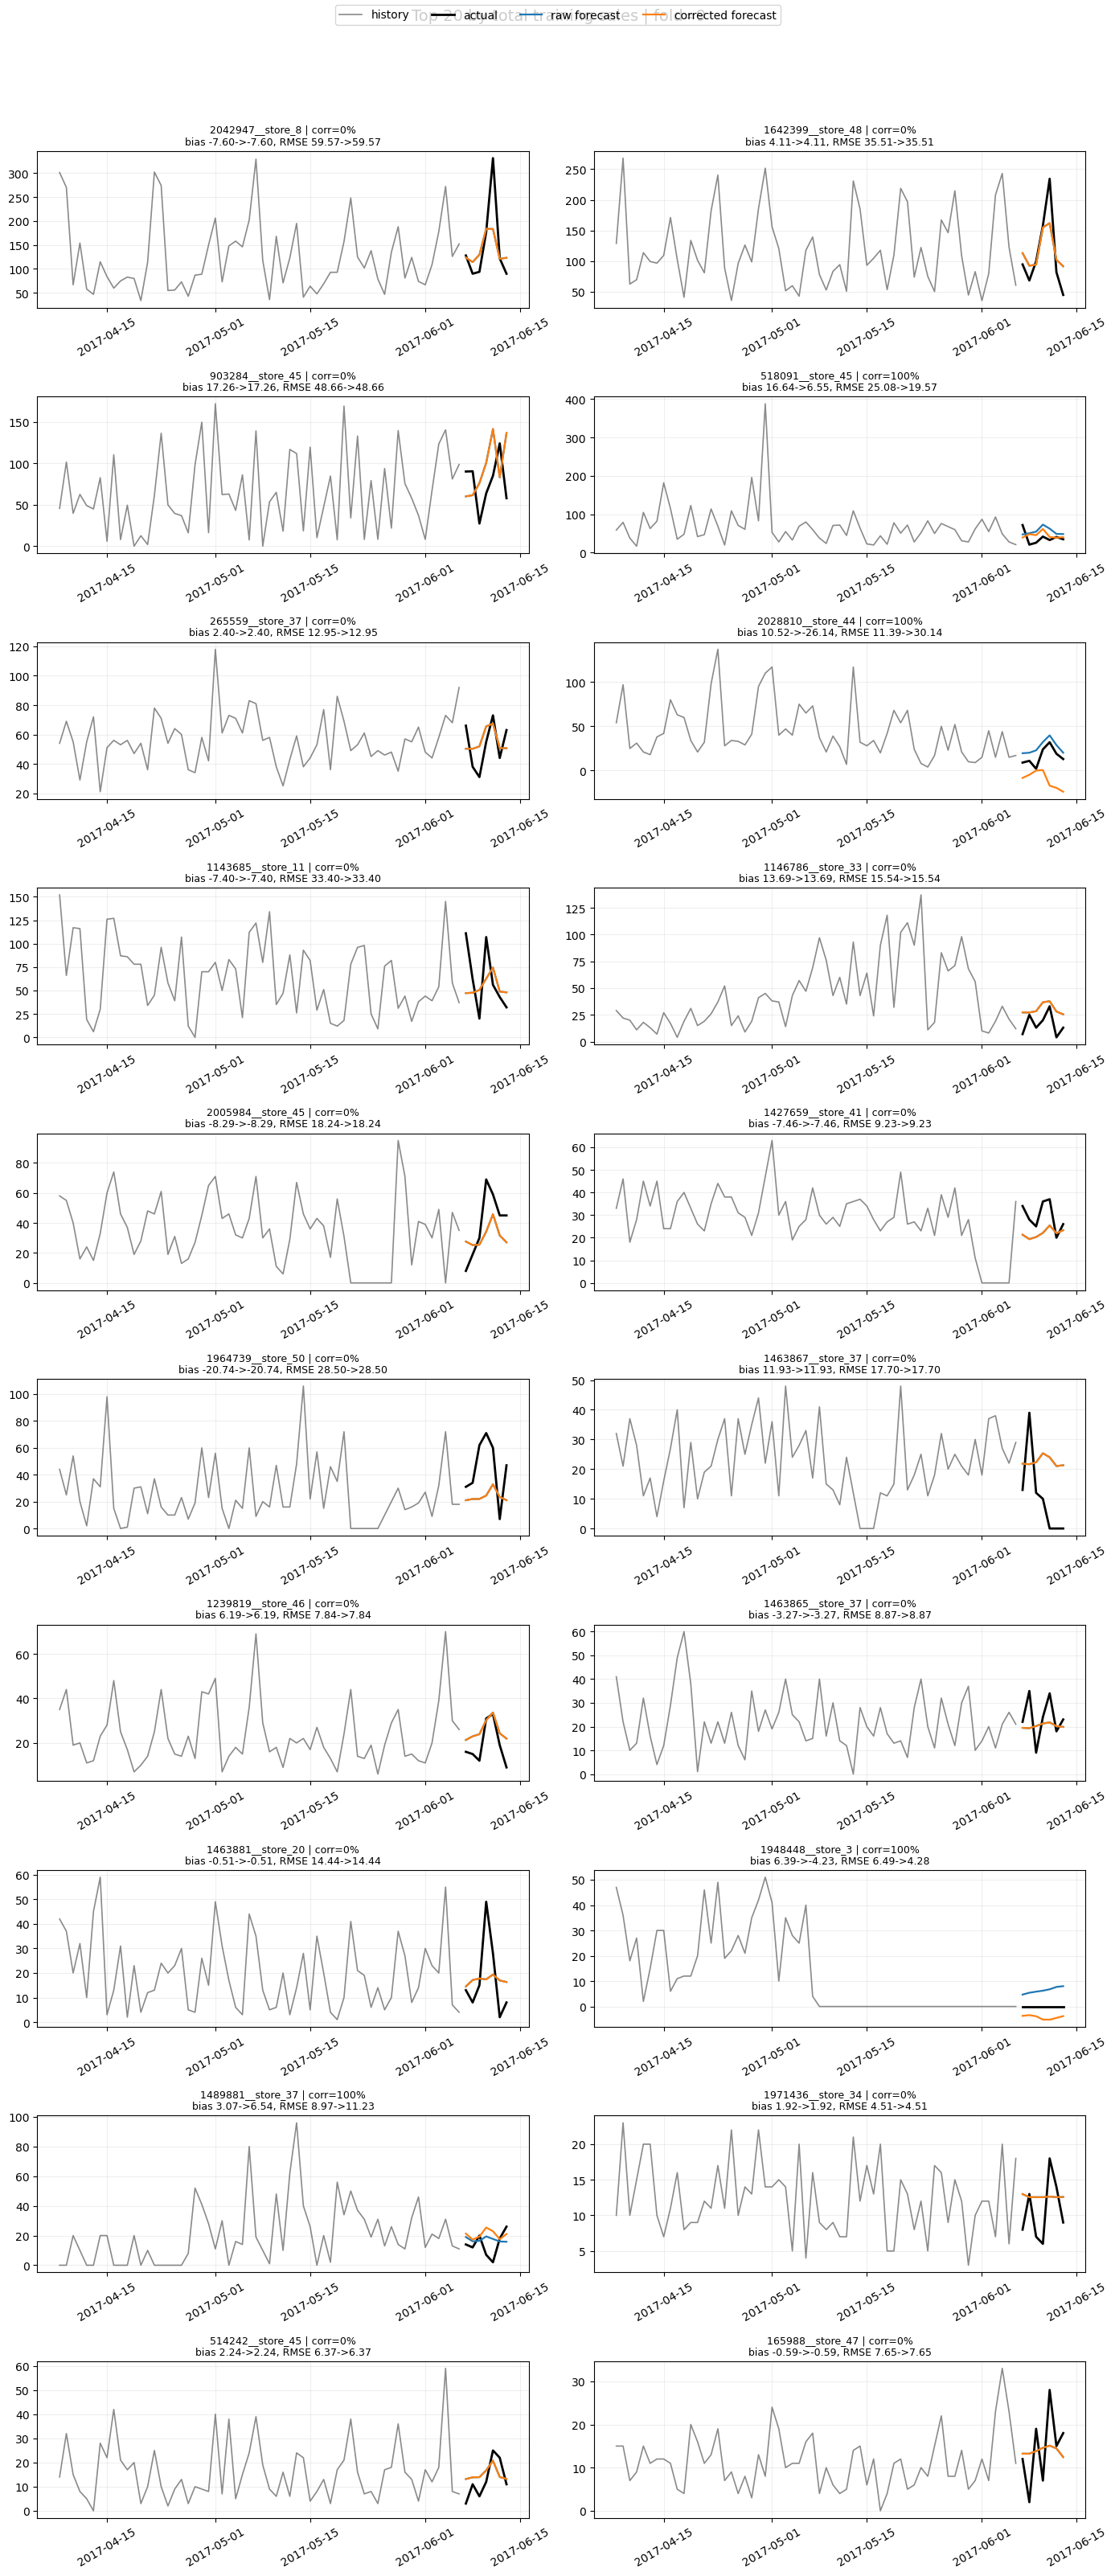

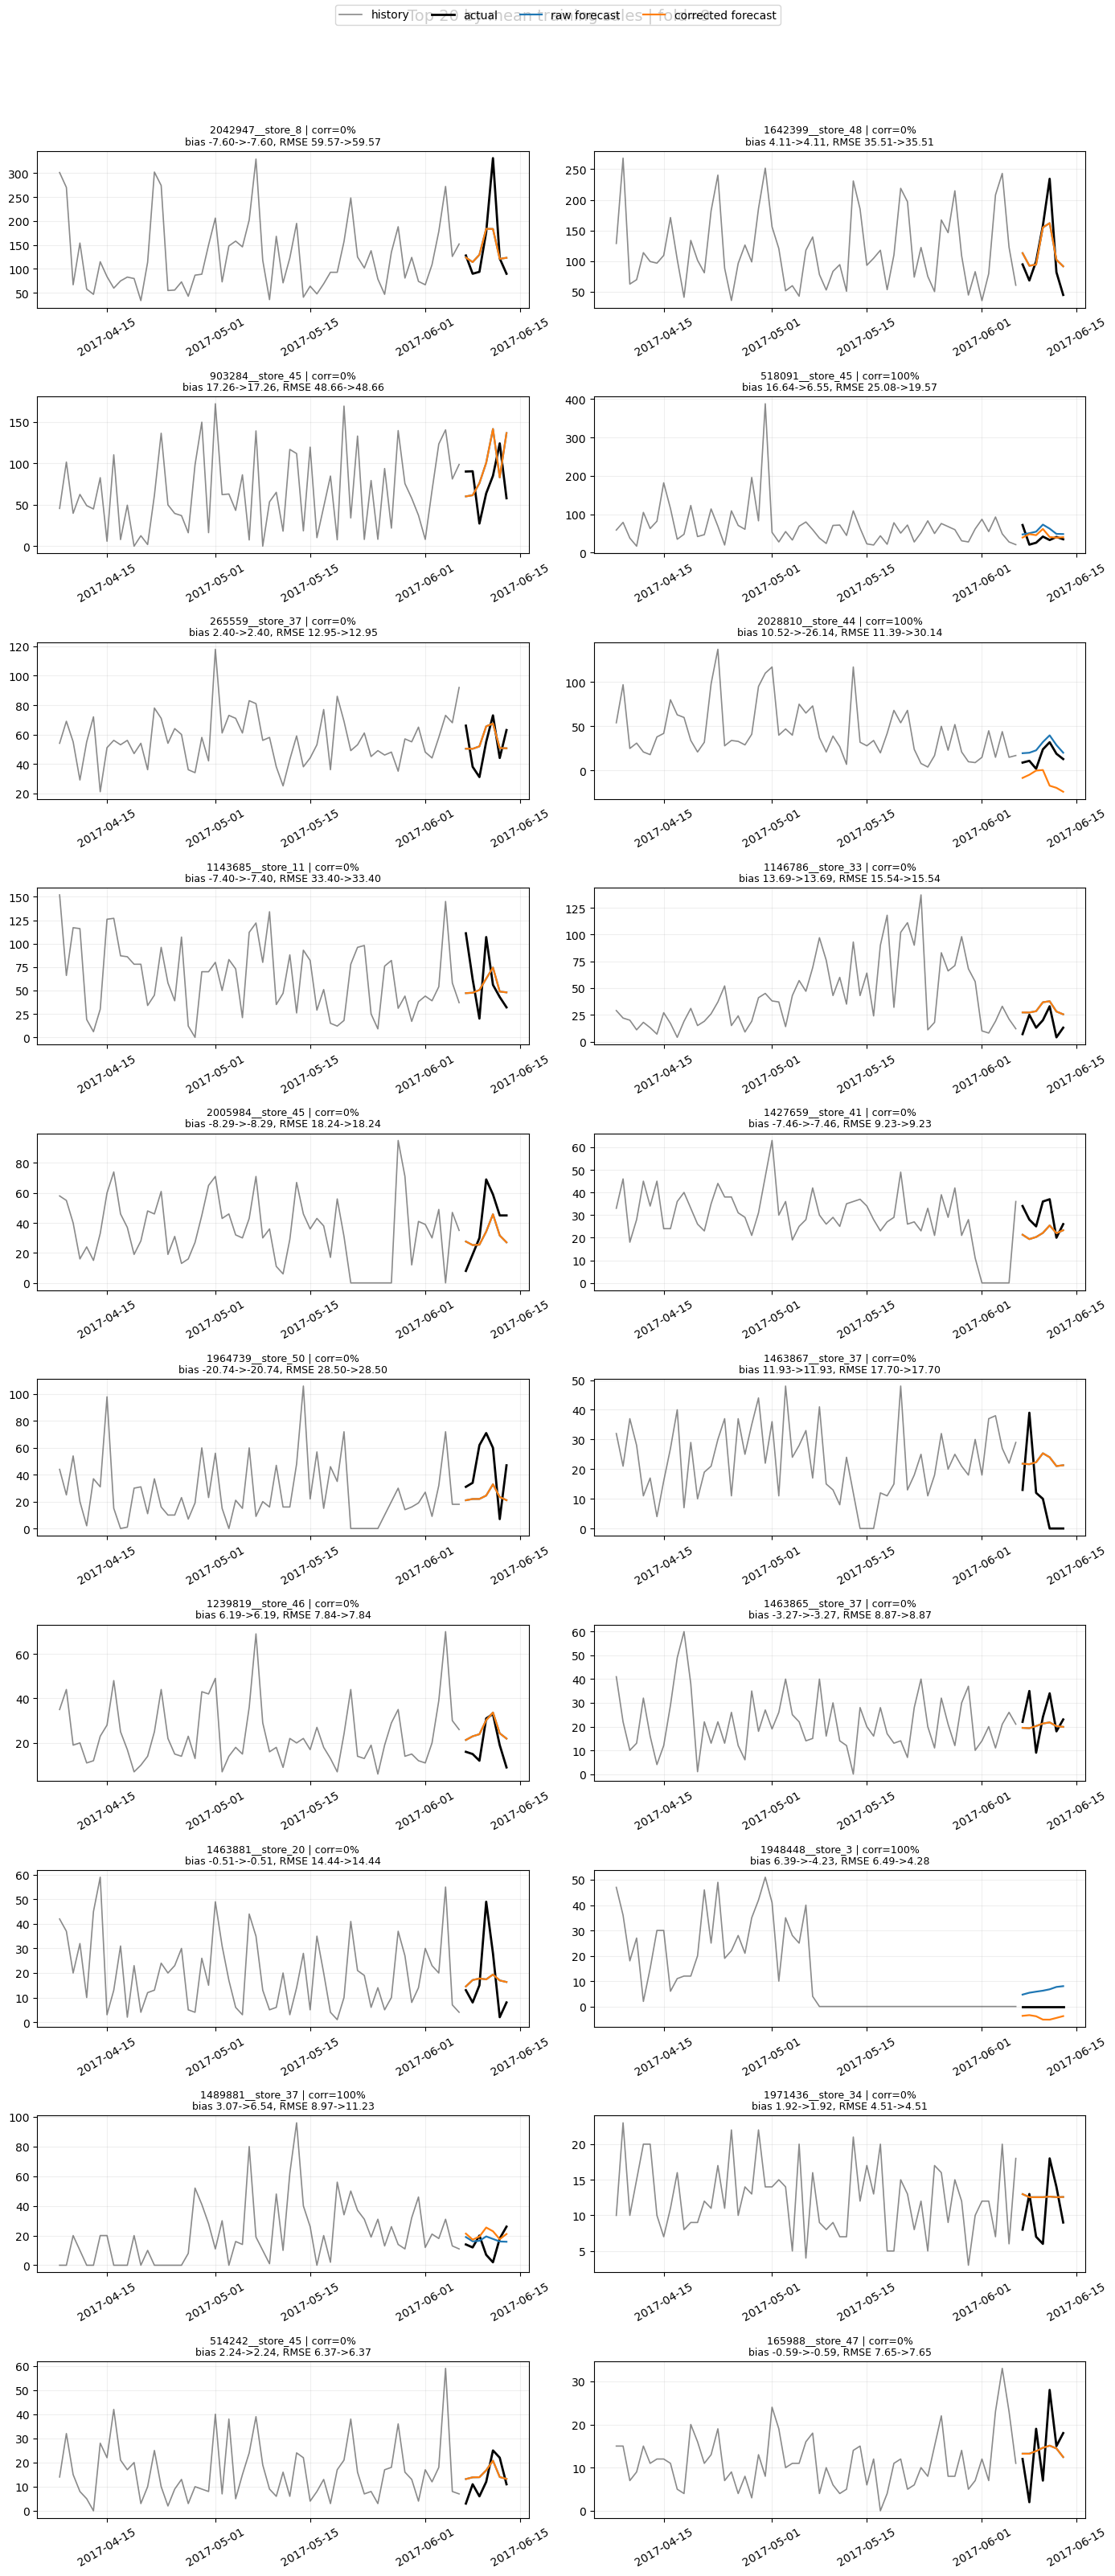

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ['train_history_df', 'forecast_df']
missing = [name for name in required if name not in globals()]
if missing:
    print(f'Missing {missing}. Run the loop and forecast_df assembly cells first.')
elif train_history_df.empty or forecast_df.empty:
    print('train_history_df or forecast_df is empty. Run the loop cell first.')
else:
    latest_train_fold = train_history_df['fold'].max()
    latest_forecast_fold = forecast_df['fold'].max()

    sales_rank_source = train_history_df[train_history_df['fold'] == latest_train_fold].copy()
    sales_rank_source['unique_id'] = sales_rank_source['unique_id'].astype(str)

    item_sales_rank_df = (
        sales_rank_source
        .groupby('unique_id', as_index=False)
        .agg(
            train_sum_sales=('y', 'sum'),
            train_mean_sales=('y', 'mean'),
            train_n_obs=('y', 'size'),
        )
    )

    forecast_eval_top_df = forecast_df.copy()
    forecast_eval_top_df['unique_id'] = forecast_eval_top_df['unique_id'].astype(str)

    def _mode_or_nan(series):
        values = series.dropna()
        if values.empty:
            return np.nan
        return values.mode().iloc[0]

    item_forecast_metrics_df = (
        forecast_eval_top_df
        .groupby('unique_id', as_index=False)
        .agg(
            n_forecast_rows=('y', 'size'),
            n_forecast_folds=('fold', 'nunique'),
            correction_rate=('was_corrected', 'mean'),
            selected_side_mode=('selected_side', _mode_or_nan),
            selected_percentile_mean=('selected_percentile', 'mean'),
            raw_bias=('raw_error', 'mean'),
            corrected_bias=('corr_error', 'mean'),
            raw_rmse=('raw_error', lambda s: np.sqrt(np.mean(np.square(s)))),
            corrected_rmse=('corr_error', lambda s: np.sqrt(np.mean(np.square(s)))),
            raw_mae=('raw_abs_error', 'mean'),
            corrected_mae=('corr_abs_error', 'mean'),
            mean_abs_adjustment=('abs_adjustment', 'mean'),
            improved_share=('improved', 'mean'),
        )
    )
    item_forecast_metrics_df['rmse_delta'] = item_forecast_metrics_df['corrected_rmse'] - item_forecast_metrics_df['raw_rmse']
    item_forecast_metrics_df['abs_bias_delta'] = item_forecast_metrics_df['corrected_bias'].abs() - item_forecast_metrics_df['raw_bias'].abs()
    item_forecast_metrics_df['bias_delta'] = item_forecast_metrics_df['corrected_bias'] - item_forecast_metrics_df['raw_bias']

    top_item_sales_diag_df = item_sales_rank_df.merge(
        item_forecast_metrics_df, on='unique_id', how='left'
    )

    metric_cols = [
        'unique_id', 'train_sum_sales', 'train_mean_sales', 'train_n_obs',
        'correction_rate', 'selected_side_mode', 'selected_percentile_mean',
        'raw_bias', 'corrected_bias', 'bias_delta', 'abs_bias_delta',
        'raw_rmse', 'corrected_rmse', 'rmse_delta',
        'raw_mae', 'corrected_mae', 'mean_abs_adjustment', 'improved_share',
        'n_forecast_folds',
    ]

    top20_by_sum_sales_df = (
        top_item_sales_diag_df
        .sort_values('train_sum_sales', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
    top20_by_mean_sales_df = (
        top_item_sales_diag_df
        .sort_values('train_mean_sales', ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    print(f'Ranking source: latest training fold {latest_train_fold}')
    print(f'Plot default: latest forecast fold {latest_forecast_fold}')
    print('Top 20 by total training sales')
    display(top20_by_sum_sales_df[metric_cols].round(4))
    print('Top 20 by mean training sales')
    display(top20_by_mean_sales_df[metric_cols].round(4))

    def plot_top20_item_forecasts(top_df, title, fold=None, history_points=60, n_cols=2):
        if fold is None:
            fold = latest_forecast_fold
        ids = top_df['unique_id'].astype(str).head(20).tolist()
        n = len(ids)
        if n == 0:
            print('No ids to plot.')
            return

        n_rows = math.ceil(n / n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 3.2 * n_rows), squeeze=False)
        axes_flat = axes.ravel()

        for ax, uid in zip(axes_flat, ids):
            hist = train_history_df[
                (train_history_df['fold'] == fold) &
                (train_history_df['unique_id'].astype(str) == uid)
            ].copy().sort_values('ds')
            fut = forecast_df[
                (forecast_df['fold'] == fold) &
                (forecast_df['unique_id'].astype(str) == uid)
            ].copy().sort_values('ds')

            if history_points is not None and not hist.empty:
                hist = hist.tail(history_points)

            if not hist.empty:
                ax.plot(hist['ds'], hist['y'], label='history', color='0.35', linewidth=1.2, alpha=0.7)
            if not fut.empty:
                ax.plot(fut['ds'], fut['y'], label='actual', color='black', linewidth=2.0)
                ax.plot(fut['ds'], fut['raw_pred'], label='raw forecast', color='tab:blue', linewidth=1.6)
                ax.plot(fut['ds'], fut['corr_pred'], label='corrected forecast', color='tab:orange', linewidth=1.6)
                raw_bias = fut['raw_error'].mean()
                corrected_bias = fut['corr_error'].mean()
                raw_rmse = np.sqrt(np.mean(np.square(fut['raw_error'])))
                corrected_rmse = np.sqrt(np.mean(np.square(fut['corr_error'])))
                correction_rate = fut['was_corrected'].mean()
                ax.set_title(
                    f'{uid} | corr={correction_rate:.0%}\n'
                    f'bias {raw_bias:.2f}->{corrected_bias:.2f}, '
                    f'RMSE {raw_rmse:.2f}->{corrected_rmse:.2f}',
                    fontsize=9,
                )
            else:
                ax.set_title(f'{uid} | no forecast rows for fold={fold}', fontsize=9)
            ax.tick_params(axis='x', labelrotation=30)
            ax.grid(alpha=0.2)

        for ax in axes_flat[n:]:
            ax.axis('off')

        handles, labels = axes_flat[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper center', ncol=4)
        fig.suptitle(f'{title} | fold={fold}', y=1.0, fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    plot_top20_item_forecasts(top20_by_sum_sales_df, 'Top 20 by total training sales')
    plot_top20_item_forecasts(top20_by_mean_sales_df, 'Top 20 by mean training sales')
